# day5_4_v10


In [ ]:
# ============================================================
# 라이브러리 설치 및 import (캐글 환경)
# ============================================================

!pip install shap --quiet
!apt-get install -y fonts-nanum > /dev/null 2>&1

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
import seaborn as sns
import lightgbm as lgb

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import MultiLabelBinarizer

# 한글 폰트 적용
nanum_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
import os
if os.path.exists(nanum_path):
    fm.fontManager.addfont(nanum_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    print('한글 폰트(NanumGothic) 적용 완료')
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
    print('NanumGothic 폰트 설치 실패. 영문 폰트로 진행합니다.')

plt.rcParams['axes.unicode_minus'] = False

RANDOM_STATE = 42
TARGET = '임신 성공 여부'
np.random.seed(RANDOM_STATE)

# ------------------------------------------------------------
# src 패키지 import
# ------------------------------------------------------------
# 이 노트북은 notebooks/ 안에 위치하므로 상위 디렉토리(프로젝트 루트)를 경로에 추가합니다.
import sys
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

from src.preprocessing import preprocess
from src.features import add_team_features, align_team_feature_categories
from src.model import run_lgbm_oof, run_catboost_oof, to_rank, weighted_ensemble, v4_params, day45_params

print('환경 설정 및 src 모듈 import가 완료되었습니다.')

In [ ]:
# ============================================================
# 데이터 로드 및 실험 옵션 토글 (캐글 환경)
# ============================================================

DATA_DIR = '//kaggle/input/datasets/min2602/my-data/'

# 캐글 작업 폴더 (제출 파일과 시각화 PNG가 저장될 곳)
OUTPUT_DIR = '/kaggle/working/'

# ------------------------------------------------------------
# 실험 옵션 설정 (이 세 가지가 본 노트북의 핵심 설정입니다)
# ------------------------------------------------------------
# N_SPLITS         : K-Fold의 K값. 본 노트북은 25-fold로 설정합니다.
#                    25이면 학습 폴드가 96%로 늘어 데이터 활용이 늘지만 학습 시간이 길어집니다.
# USE_RANK_AVG     : 앙상블 시 각 모델 예측을 순위(rank)로 변환한 후 평균할지 결정합니다.
#                    AUC는 순위 기반 지표이므로, 모델 간 확률 분포가 다를 때 도움이 됩니다.
# USE_DAY45_PARAMS : day4_5 실험에서 탐색한 100회 Optuna 결과 파라미터로 교체할지 결정합니다.
#                    참고용 비교 옵션이며, 기본값(v4 파라미터)이 가장 안정적입니다.

N_SPLITS         = 25
USE_RANK_AVG     = True
USE_DAY45_PARAMS = False

# ------------------------------------------------------------
# GPU 사용 가능 여부 자동 감지
# ------------------------------------------------------------
# 캐글 우측 Settings에서 'Accelerator'를 'GPU P100' 또는 'GPU T4 x2'로 선택하면 GPU가 활성화됩니다.
# CatBoost는 GPU에서 약 3~5배 빠르게 학습됩니다.
import subprocess
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True, timeout=5)
    USE_GPU = result.returncode == 0
except Exception:
    USE_GPU = False

if USE_GPU:
    print('[GPU 감지] CatBoost를 GPU로 가속합니다.')
else:
    print('[CPU 모드] GPU가 감지되지 않아 CPU로 학습합니다.')

# ------------------------------------------------------------
# 데이터 파일 로드
# ------------------------------------------------------------
df_raw      = pd.read_csv(DATA_DIR + 'train.csv')
df_test_raw = pd.read_csv(DATA_DIR + 'test.csv')

# 컬럼명 양 끝에 보이지 않는 공백이 끼어 있는 경우가 있어 일괄 정리합니다.
# 이 처리를 빠뜨리면 같은 이름처럼 보이는 컬럼이 다르게 인식되어 디버깅이 매우 까다로워집니다.
df_raw.columns      = [c.strip() for c in df_raw.columns]
df_test_raw.columns = [c.strip() for c in df_test_raw.columns]

print(f'학습 데이터: {df_raw.shape[0]:,}행 × {df_raw.shape[1]}열')
print(f'평가 데이터: {df_test_raw.shape[0]:,}행 × {df_test_raw.shape[1]}열')
print()
print('현재 실험 설정')
print(f'  N_SPLITS         = {N_SPLITS}')
print(f'  USE_RANK_AVG     = {USE_RANK_AVG}')
print(f'  USE_DAY45_PARAMS = {USE_DAY45_PARAMS}')
print(f'  USE_GPU          = {USE_GPU}')
print()
print('타겟 분포 (임신 성공 여부)')
print(df_raw[TARGET].value_counts())
print()
print('실패와 성공의 비율이 약 2.87 대 1로, 클래스 불균형이 존재합니다.')
print('이 부분은 모델 학습 시 scale_pos_weight로 보정합니다.')

[GPU 감지] CatBoost를 GPU로 가속합니다.
학습 데이터: 256,351행 × 69열
평가 데이터: 90,067행 × 68열

현재 실험 설정
  N_SPLITS         = 25
  USE_RANK_AVG     = True
  USE_DAY45_PARAMS = False
  USE_GPU          = True

타겟 분포 (임신 성공 여부)
임신 성공 여부
0    190123
1     66228
Name: count, dtype: int64

실패와 성공의 비율이 약 2.87 대 1로, 클래스 불균형이 존재합니다.
이 부분은 모델 학습 시 scale_pos_weight로 보정합니다.


---
##  Part 1. 탐색적 데이터 분석 (EDA)


In [ ]:
# ============================================================
# EDA 전용 DataFrame 준비
# ============================================================

eda_df = df_raw.copy()
eda_df.columns = [c.strip() for c in eda_df.columns]

# ------------------------------------------------------------
# 나이 변수 수치화 (시각화용)
# ------------------------------------------------------------
# 원본은 '만35-37세'와 같은 구간 형태의 문자열입니다.
# 시각화에서 비교하기 쉽도록 구간의 중앙값과 임상 위험도 분류를 함께 부여합니다.
# 임상적으로 만 35세 이상부터 자연 임신 성공률이 의미 있게 떨어지므로 '고위험'으로,
# 만 40세 이상은 '초고위험'으로 분류했습니다. 만 45세 이상은 자가 난자 임신이 거의 어렵고
# 기증 난자 비율이 높아지는 구간이라 별도로 보아야 합니다.

age_info_eda = {
    '만18-34세': {'val': 26.0, 'risk': '정상_임신군'},
    '만35-37세': {'val': 36.0, 'risk': '고위험_임신군'},
    '만38-39세': {'val': 38.5, 'risk': '고위험_임신군'},
    '만40-42세': {'val': 41.0, 'risk': '초고위험_임신군'},
    '만43-44세': {'val': 43.5, 'risk': '초고위험_임신군'},
    '만45-50세': {'val': 47.5, 'risk': '초고위험_임신군'},
    '알 수 없음': {'val': np.nan, 'risk': '미분류'},
}
eda_df['나이_수치'] = eda_df['시술 당시 나이'].map(
    lambda x: age_info_eda.get(x, {'val': np.nan})['val'])
eda_df['임신_위험도_범주'] = eda_df['시술 당시 나이'].map(
    lambda x: age_info_eda.get(x, {'risk': '미분류'})['risk'])

# ------------------------------------------------------------
# 시술 유형 단순 분류 (시각화용)
# ------------------------------------------------------------
# 원본의 '특정 시술 유형'은 항목이 매우 다양해 시각화에 그대로 쓰기 어렵습니다.
# 임상적으로 의미 있는 네 가지 큰 그룹으로 묶어 사용합니다.
#   Blastocyst_Transfer : 배반포 단계까지 배양한 배아를 이식하는 방법. 일반적으로 성공률이 가장 높습니다.
#   ICSI                : 정자를 난자에 직접 주입하는 미세주입술.
#   IVF                 : 표준 시험관 시술.
#   IUI                 : 인공수정. 자궁 내로 정자를 주입하는 방식이며 정의상 본인 난자를 사용합니다.

def classify_tx(x):
    t = str(x).upper().strip()
    if 'BLASTOCYST' in t: return 'Blastocyst_Transfer'
    if 'ICSI' in t:       return 'ICSI'
    if 'IVF' in t:        return 'IVF'
    if 'IUI' in t:        return 'IUI'
    return 'Unknown'

eda_df['시술_분류_그룹'] = eda_df['특정 시술 유형'].fillna('').apply(classify_tx)

# IUI는 정의상 본인의 난자를 사용하므로, 이 그룹의 '난자 출처'를 일괄로 본인 제공으로 정리합니다.
# 일부 행에서 난자 출처가 누락되어 있을 때 이 보정이 시각화에서 도움이 됩니다.
eda_df.loc[eda_df['시술_분류_그룹'] == 'IUI', '난자 출처'] = '본인 제공'

print('EDA 전용 DataFrame이 준비되었습니다.')
print()
print('시술 분류별 건수')
print(eda_df['시술_분류_그룹'].value_counts())

EDA 전용 DataFrame이 준비되었습니다.

시술 분류별 건수
시술_분류_그룹
ICSI                   126927
IVF                     93320
Unknown                 27136
IUI                      6100
Blastocyst_Transfer      2868
Name: count, dtype: int64


### EDA 1 — 타겟 클래스 분포


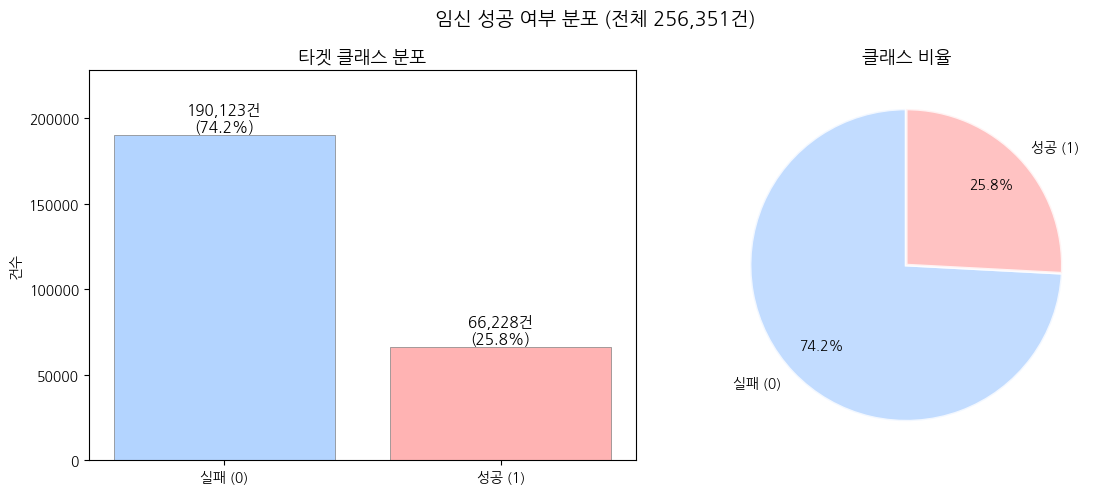

클래스 불균형 비율 (scale_pos_weight): 2.871
실패가 성공보다 약 2.87배 많은 구조이며, 모델 학습 시 보정이 필요합니다.


In [ ]:
# ============================================================
# 타겟 클래스 분포 확인
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (1) 절대 건수 막대 그래프
counts = df_raw[TARGET].value_counts()
bars = axes[0].bar(['실패 (0)', '성공 (1)'], counts.values,
                   color=['#B3D4FF', '#FFB3B3'], edgecolor='gray', linewidth=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}건\n({val/len(df_raw)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('타겟 클래스 분포', fontsize=13)
axes[0].set_ylabel('건수')
axes[0].set_ylim(0, max(counts.values) * 1.2)

# (2) 비율 파이 차트
axes[1].pie(counts.values, labels=['실패 (0)', '성공 (1)'],
            colors=['#B3D4FF', '#FFB3B3'], autopct='%1.1f%%',
            startangle=90, pctdistance=0.75,
            wedgeprops=dict(alpha=0.8, edgecolor='white', linewidth=2))
axes[1].set_title('클래스 비율', fontsize=13)

plt.suptitle(f'임신 성공 여부 분포 (전체 {len(df_raw):,}건)', fontsize=14)
plt.tight_layout()
plt.show()

# scale_pos_weight는 음성 클래스 건수를 양성 클래스 건수로 나눈 값입니다.
# LightGBM과 CatBoost에 이 값을 전달하면 양성 샘플의 손실에 가중치가 곱해져,
# 불균형한 데이터에서도 모델이 소수 클래스의 패턴을 잊지 않도록 도와줍니다.
scale_pos_weight = (df_raw[TARGET]==0).sum() / (df_raw[TARGET]==1).sum()
print(f'클래스 불균형 비율 (scale_pos_weight): {scale_pos_weight:.3f}')
print('실패가 성공보다 약 2.87배 많은 구조이며, 모델 학습 시 보정이 필요합니다.')

### EDA 2 — 결측치 통계


In [ ]:
# ============================================================
# 결측치 점검
# ============================================================

missing = df_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_df = pd.DataFrame({'결측 건수': missing, '결측률(%)': missing_pct})
missing_df = missing_df[missing_df['결측 건수'] > 0]

print(f'결측치가 존재하는 컬럼은 총 {len(missing_df)}개입니다.')
print()
print(missing_df.to_string())

결측치가 존재하는 컬럼은 총 31개입니다.

                        결측 건수  결측률(%)
난자 해동 경과일              254915    99.4
PGS 시술 여부              254422    99.2
PGD 시술 여부              254172    99.1
착상 전 유전 검사 사용 여부       253633    98.9
임신 시도 또는 마지막 임신 경과 연수  246981    96.3
배아 해동 경과일              215982    84.3
난자 채취 경과일               57488    22.4
난자 혼합 경과일               53735    21.0
배아 이식 경과일               43566    17.0
미세주입 후 저장된 배아 수          6291     2.5
해동된 배아 수                 6291     2.5
저장된 배아 수                 6291     2.5
미세주입 배아 이식 수             6291     2.5
대리모 여부                   6291     2.5
단일 배아 이식 여부              6291     2.5
착상 전 유전 진단 사용 여부         6291     2.5
배아 생성 주요 이유              6291     2.5
미세주입에서 생성된 배아 수          6291     2.5
이식된 배아 수                 6291     2.5
총 생성 배아 수                6291     2.5
기증 배아 사용 여부              6291     2.5
미세주입된 난자 수               6291     2.5
혼합된 난자 수                 6291     2.5
해동 난자 수                  6291     2.5
수집된 신선 난자 수              

### EDA 3 — 연령대별 임신 성공률 (핵심 발견)


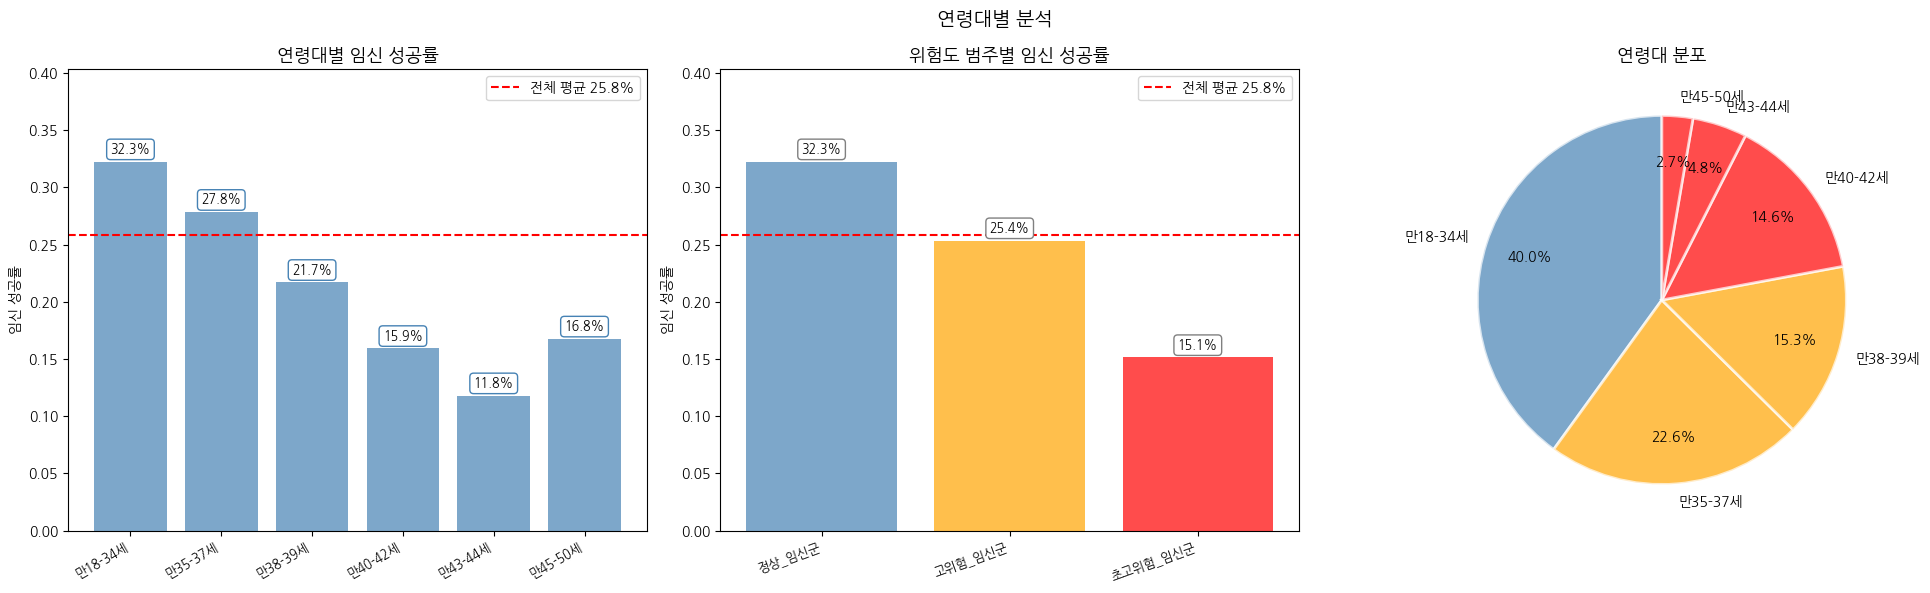

관찰: 나이가 들수록 임신 성공률이 점진적으로 낮아지며,
만 45-50세 구간에서는 기증 난자 사용이 늘어나 그래프가 소폭 반등합니다.


In [ ]:
# ============================================================
# 연령대별 임신 성공률 분석
# ============================================================

age_order = ['만18-34세', '만35-37세', '만38-39세', '만40-42세', '만43-44세', '만45-50세']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (1) 6단계 연령대별 막대 그래프
age_success = eda_df[eda_df['시술 당시 나이'] != '알 수 없음'].groupby(
    '시술 당시 나이')[TARGET].mean().reindex(age_order)
bars = axes[0].bar(range(len(age_success)), age_success.values,
                   color='steelblue', alpha=0.7)
axes[0].set_xticks(range(len(age_success)))
axes[0].set_xticklabels(age_success.index, rotation=30, ha='right', fontsize=9)
axes[0].set_title('연령대별 임신 성공률', fontsize=13)
axes[0].set_ylabel('임신 성공률')
axes[0].set_ylim(0, max(age_success.values) * 1.25)
axes[0].axhline(y=df_raw[TARGET].mean(), color='red', linestyle='--',
                label=f'전체 평균 {df_raw[TARGET].mean()*100:.1f}%')
axes[0].legend()
for bar, val in zip(bars, age_success.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor='steelblue', linewidth=1))

# (2) 3단계 임상 위험군별 그래프
risk_order = ['정상_임신군', '고위험_임신군', '초고위험_임신군']
risk_success = eda_df[eda_df['임신_위험도_범주'] != '미분류'].groupby(
    '임신_위험도_범주')[TARGET].mean().reindex(risk_order)
risk_colors = {'정상_임신군': 'steelblue', '고위험_임신군': 'orange', '초고위험_임신군': 'red'}
bar_colors = [risk_colors[r] for r in risk_order]
bars2 = axes[1].bar(range(len(risk_success)), risk_success.values,
                    color=bar_colors, alpha=0.7)
axes[1].set_xticks(range(len(risk_success)))
axes[1].set_xticklabels(risk_success.index, rotation=20, ha='right', fontsize=9)
axes[1].set_title('위험도 범주별 임신 성공률', fontsize=13)
axes[1].set_ylabel('임신 성공률')
axes[1].set_ylim(0, max(risk_success.values) * 1.25)
axes[1].axhline(y=df_raw[TARGET].mean(), color='red', linestyle='--',
                label=f'전체 평균 {df_raw[TARGET].mean()*100:.1f}%')
axes[1].legend()
for bar, val in zip(bars2, risk_success.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor='gray', linewidth=1))

# (3) 연령대별 인구 분포
age_counts = eda_df[eda_df['시술 당시 나이'].isin(age_order)].groupby(
    '시술 당시 나이').size().reindex(age_order)
age_colors_pie = ['steelblue', 'orange', 'orange', 'red', 'red', 'red']
axes[2].pie(age_counts.values, labels=age_counts.index,
            colors=age_colors_pie, autopct='%1.1f%%',
            startangle=90, pctdistance=0.75,
            wedgeprops=dict(alpha=0.7, edgecolor='white', linewidth=2))
axes[2].set_title('연령대 분포', fontsize=13)

plt.suptitle('연령대별 분석', fontsize=14)
plt.tight_layout()
plt.show()
print('관찰: 나이가 들수록 임신 성공률이 점진적으로 낮아지며,')
print('만 45-50세 구간에서는 기증 난자 사용이 늘어나 그래프가 소폭 반등합니다.')

### EDA 4 — 시술 유형별 임신 성공률


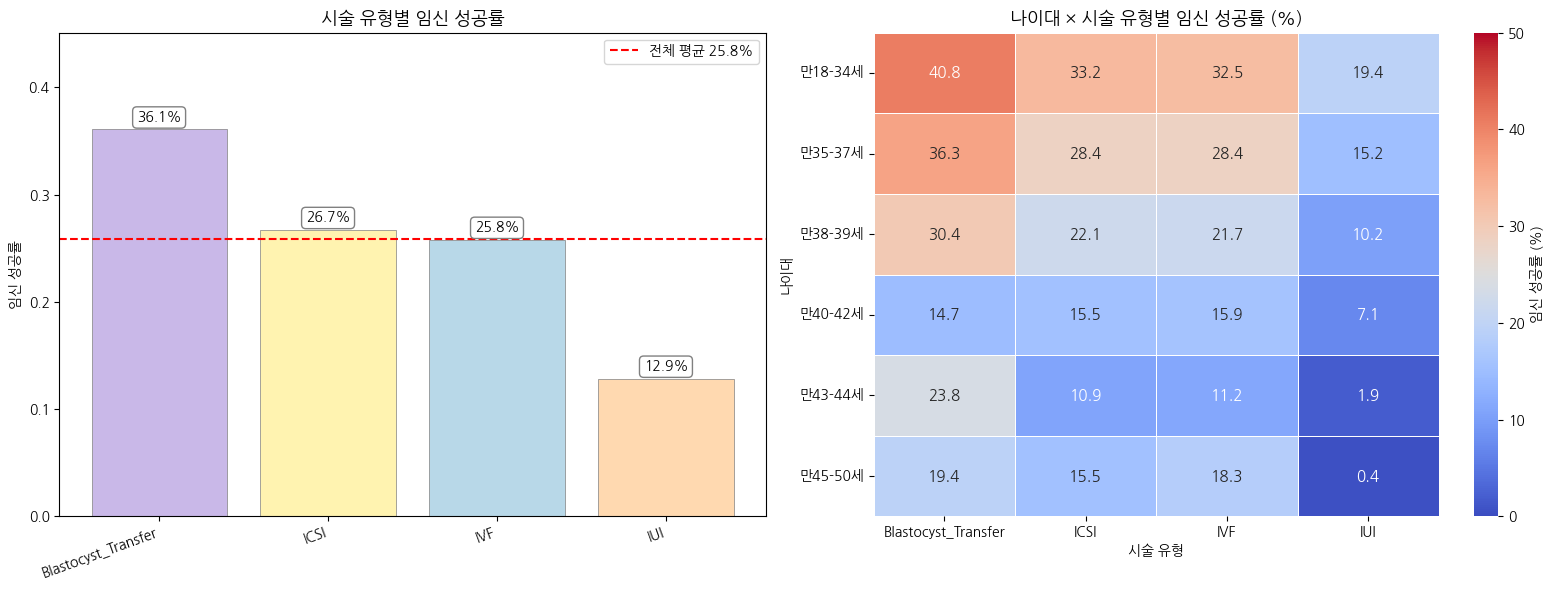

In [ ]:
# ============================================================
# 시술 유형별 임신 성공률 분석
# ============================================================

treatment_order = ['Blastocyst_Transfer', 'ICSI', 'IVF', 'IUI']
treatment_colors = {
    'Blastocyst_Transfer': '#C9B8E8',
    'ICSI': '#FFF3B0',
    'IVF': '#B8D8E8',
    'IUI': '#FFD9B0',
}
age_order = ['만18-34세', '만35-37세', '만38-39세', '만40-42세', '만43-44세', '만45-50세']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) 시술 유형별 임신 성공률 막대 그래프
tx_success = eda_df[eda_df['시술_분류_그룹'] != 'Unknown'].groupby(
    '시술_분류_그룹')[TARGET].mean().reindex(treatment_order).dropna()
bar_colors = [treatment_colors[t] for t in tx_success.index]
bars = axes[0].bar(range(len(tx_success)), tx_success.values,
                   color=bar_colors, edgecolor='gray', linewidth=0.5)
axes[0].set_xticks(range(len(tx_success)))
axes[0].set_xticklabels(tx_success.index, rotation=20, ha='right', fontsize=10)
axes[0].set_title('시술 유형별 임신 성공률', fontsize=13)
axes[0].set_ylabel('임신 성공률')
axes[0].set_ylim(0, max(tx_success.values) * 1.25)
axes[0].axhline(y=df_raw[TARGET].mean(), color='red', linestyle='--',
                label=f'전체 평균 {df_raw[TARGET].mean()*100:.1f}%')
axes[0].legend()
for bar, val in zip(bars, tx_success.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor='gray', linewidth=1))

# (2) 나이대 × 시술 유형 히트맵
df_filtered = eda_df[
    (eda_df['시술 당시 나이'].isin(age_order)) &
    (eda_df['시술_분류_그룹'].isin(treatment_order))
]
pivot = df_filtered.groupby(['시술 당시 나이', '시술_분류_그룹'])[TARGET].mean().unstack()
pivot = pivot.reindex(age_order)[treatment_order]
pivot_pct = (pivot * 100).round(1)

sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='coolwarm',
            vmin=0, vmax=50, linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'label': '임신 성공률 (%)'}, ax=axes[1])
axes[1].set_title('나이대 × 시술 유형별 임신 성공률 (%)', fontsize=13)
axes[1].set_xlabel('시술 유형', fontsize=10)
axes[1].set_ylabel('나이대', fontsize=10)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### EDA 5 — 이식된 배아 수별 임신 성공률 (모델 1위 변수)


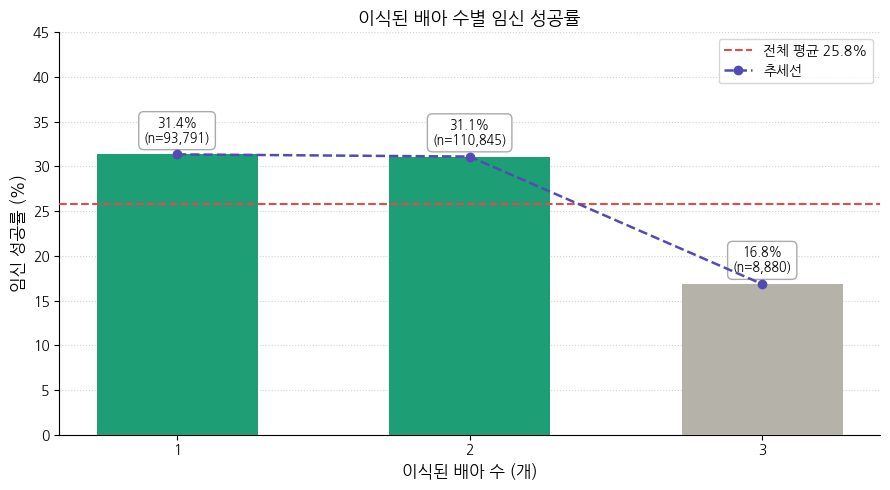

관찰: 한 개의 배아만 이식한 경우의 임신 성공률이 가장 높습니다.
해석: 배아의 질이 좋을 때 단일 이식을 선택하는 임상 패턴이 반영된 결과로 볼 수 있습니다.


In [ ]:
# ============================================================
# 이식된 배아 수별 임신 성공률
# ============================================================

emb_data = eda_df.groupby('이식된 배아 수')[TARGET].agg(['mean', 'count']).reset_index()
emb_data.columns = ['이식수', '성공률', '샘플수']
emb_data = emb_data[emb_data['이식수'] > 0]   # 0개는 시술이 이식 단계까지 가지 않은 케이스라 제외합니다.

# 평균보다 높은 그룹은 진한 초록, 평균 이하는 회색으로 표시해 가독성을 높였습니다.
colors = ['#B4B2A9' if v < df_raw[TARGET].mean() else '#1D9E75'
          for v in emb_data['성공률']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(emb_data['이식수'].astype(int), emb_data['성공률'] * 100,
              color=colors, width=0.55, zorder=3)
ax.axhline(df_raw[TARGET].mean()*100, color='#E24B4A', lw=1.5, ls='--',
           zorder=4, label=f'전체 평균 {df_raw[TARGET].mean()*100:.1f}%')

for bar, (_, row) in zip(bars, emb_data.iterrows()):
    ax.annotate(
        f"{row['성공률']*100:.1f}%\n(n={int(row['샘플수']):,})",
        xy=(bar.get_x() + bar.get_width()/2, row['성공률']*100),
        xytext=(0, 7), textcoords='offset points',
        ha='center', va='bottom', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#aaa', lw=1)
    )
ax.plot(emb_data['이식수'].astype(int), emb_data['성공률']*100,
        'o--', color='#534AB7', lw=1.8, ms=6, zorder=5, label='추세선')

ax.set_xlabel('이식된 배아 수 (개)', fontsize=12)
ax.set_ylabel('임신 성공률 (%)', fontsize=12)
ax.set_xticks(emb_data['이식수'].astype(int))
ax.set_ylim(0, 45)
ax.yaxis.grid(True, linestyle=':', color='#D3D1C7', zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10)
ax.set_title('이식된 배아 수별 임신 성공률', fontsize=13)
plt.tight_layout()
plt.show()
print('관찰: 한 개의 배아만 이식한 경우의 임신 성공률이 가장 높습니다.')
print('해석: 배아의 질이 좋을 때 단일 이식을 선택하는 임상 패턴이 반영된 결과로 볼 수 있습니다.')

### EDA 6 — 동결 배아 사용 여부와 기증 난자 사용 비율


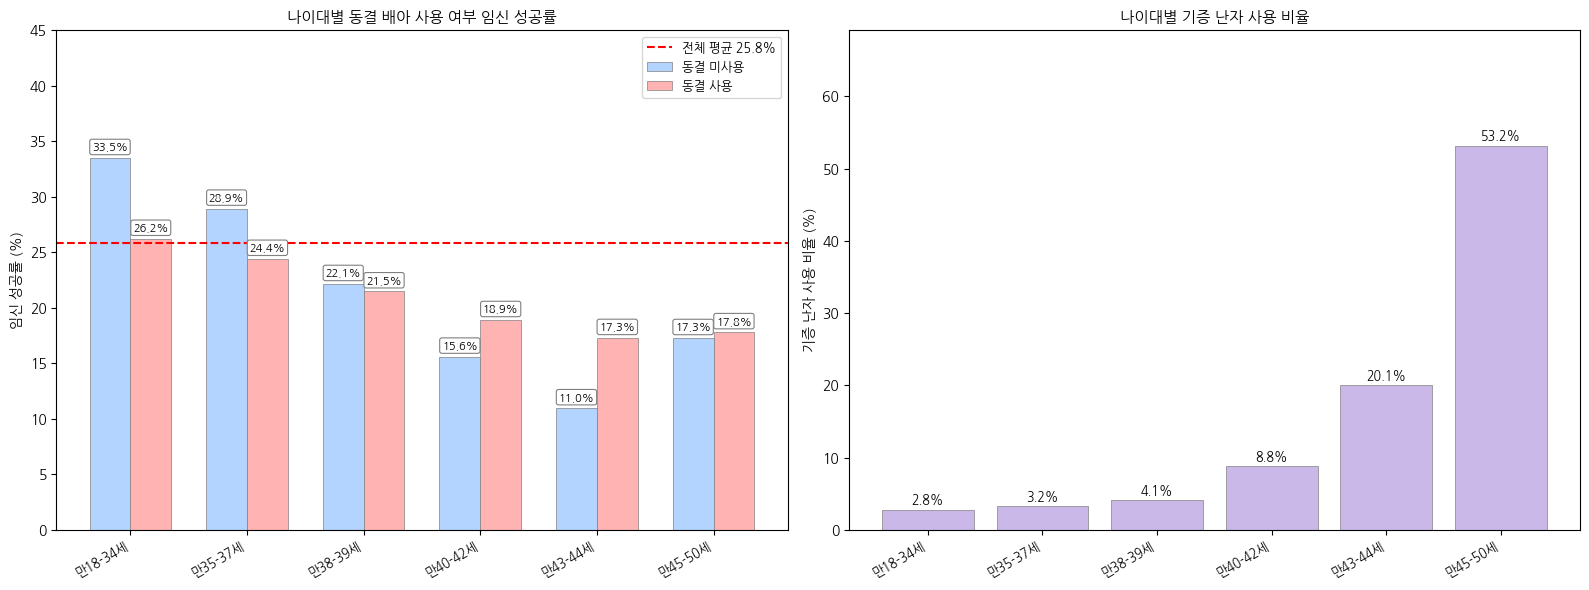

관찰: 만 40세 이상에서 동결 배아 사용 시 신선 배아보다 성공률이 높은 역전 현상이 나타납니다.
해석: 고령일수록 기증 난자 사용 비율이 함께 증가하며, 만 45-50세 구간의 성공률 회복은
이 두 요인이 결합한 결과로 볼 수 있습니다.


In [ ]:
# ============================================================
# 동결 배아 사용 여부와 기증 난자 사용 비율 분석
# ============================================================

age_order = ['만18-34세', '만35-37세', '만38-39세', '만40-42세', '만43-44세', '만45-50세']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) 나이대별 동결 배아 사용 여부 성공률
pivot_frozen = eda_df[eda_df['시술 당시 나이'].isin(age_order)].groupby(
    ['시술 당시 나이', '동결 배아 사용 여부'])[TARGET].mean().unstack() * 100
pivot_frozen = pivot_frozen.reindex(age_order)

x = np.arange(len(age_order))
width = 0.35
bars1 = axes[0].bar(x - width/2, pivot_frozen[0], width,
                    label='동결 미사용', color='#B3D4FF', edgecolor='gray', linewidth=0.5)
bars2 = axes[0].bar(x + width/2, pivot_frozen[1], width,
                    label='동결 사용', color='#FFB3B3', edgecolor='gray', linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(age_order, rotation=30, ha='right', fontsize=9)
axes[0].set_title('나이대별 동결 배아 사용 여부 임신 성공률', fontsize=11)
axes[0].set_ylabel('임신 성공률 (%)')
axes[0].set_ylim(0, 45)
axes[0].axhline(y=df_raw[TARGET].mean()*100, color='red', linestyle='--',
                label=f'전체 평균 {df_raw[TARGET].mean()*100:.1f}%')
axes[0].legend(fontsize=9)
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.5,
                     f'{h:.1f}%', ha='center', va='bottom', fontsize=8,
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                               edgecolor='gray', linewidth=0.8))

# (2) 나이대별 기증 난자 사용 비율
donor_rate = eda_df[eda_df['시술 당시 나이'].isin(age_order)].groupby(
    '시술 당시 나이').apply(
    lambda g: (g['난자 출처'] == '기증 제공').mean() * 100
).reindex(age_order)
bars3 = axes[1].bar(range(len(age_order)), donor_rate.values,
                    color='#C9B8E8', edgecolor='gray', linewidth=0.5)
axes[1].set_xticks(range(len(age_order)))
axes[1].set_xticklabels(age_order, rotation=30, ha='right', fontsize=9)
axes[1].set_title('나이대별 기증 난자 사용 비율', fontsize=11)
axes[1].set_ylabel('기증 난자 사용 비율 (%)')
axes[1].set_ylim(0, max(donor_rate.values) * 1.3)
for bar, val in zip(bars3, donor_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
print('관찰: 만 40세 이상에서 동결 배아 사용 시 신선 배아보다 성공률이 높은 역전 현상이 나타납니다.')
print('해석: 고령일수록 기증 난자 사용 비율이 함께 증가하며, 만 45-50세 구간의 성공률 회복은')
print('이 두 요인이 결합한 결과로 볼 수 있습니다.')

### EDA 7 — 시술 / 임신 / 출산 횟수별 임신 성공률


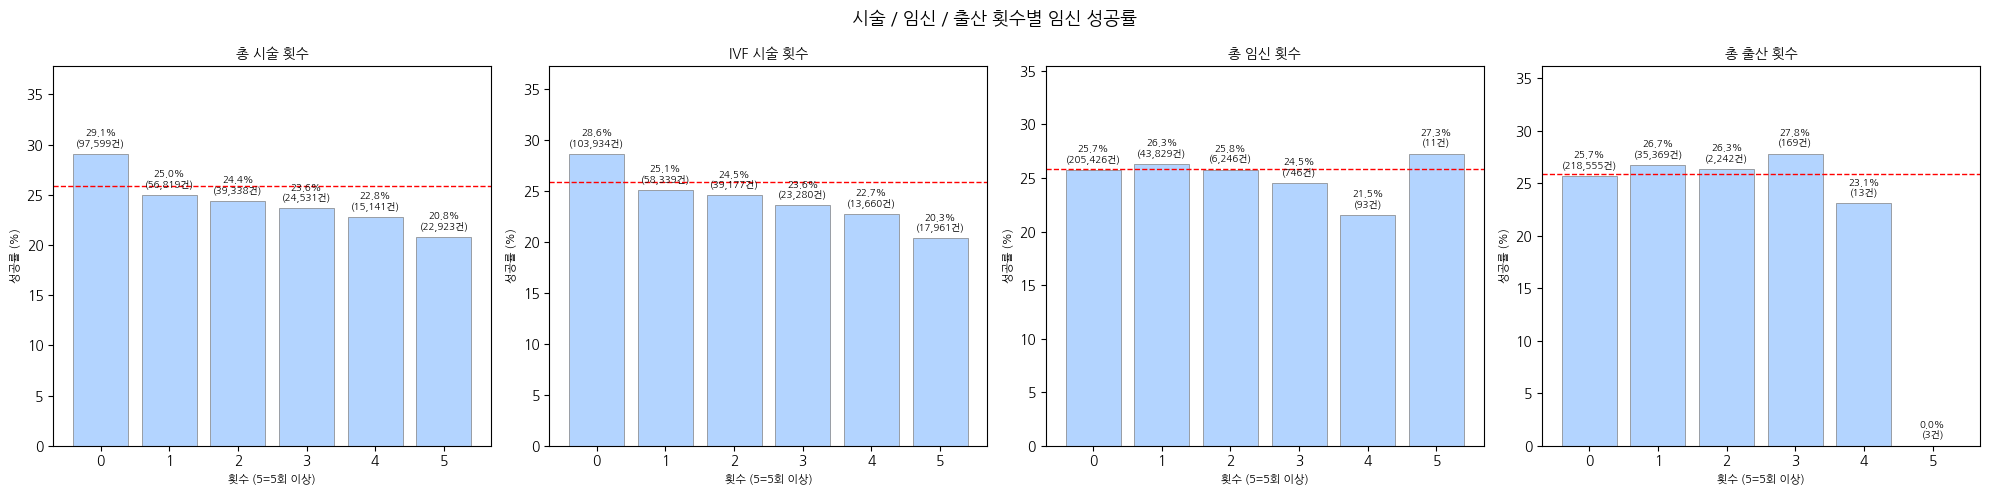

관찰: 모든 횟수 변수에서 0회(첫 시술 또는 첫 임신)일 때 성공률이 가장 높습니다.
해석: 횟수가 누적될수록 더 까다로운 케이스가 모이는 경향이 반영된 결과로 볼 수 있습니다.


In [ ]:
# ============================================================
# 시술 / 임신 / 출산 횟수별 임신 성공률
# ============================================================

def parse_count_eda(series):
    """
    문자열 형태의 횟수 컬럼을 정수로 변환합니다 (시각화 전용).
      str.extract(r'(\d+)') : 첫 번째 숫자 그룹을 추출합니다.
      fillna(0)              : 추출에 실패한 행은 0으로 처리합니다.
      clip(upper=5)          : 시각화 단순화를 위해 5회 이상은 5로 묶습니다.
    """
    return series.astype(str).str.extract(r'(\d+)')[0].fillna(0).astype(int).clip(upper=5)

cycle_cols_eda = {
    '총 시술 횟수': '총 시술 횟수',
    'IVF 시술 횟수': 'IVF 시술 횟수',
    '총 임신 횟수': '총 임신 횟수',
    '총 출산 횟수': '총 출산 횟수',
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (col_orig, col_label) in zip(axes, cycle_cols_eda.items()):
    parsed = parse_count_eda(eda_df[col_orig])
    success_by_count = eda_df.groupby(parsed)[TARGET].mean() * 100
    count_by_group   = eda_df.groupby(parsed).size()
    bars = ax.bar(success_by_count.index, success_by_count.values,
                  color='#B3D4FF', edgecolor='gray', linewidth=0.5)
    ax.set_title(col_label, fontsize=10)
    ax.set_xlabel('횟수 (5=5회 이상)', fontsize=8)
    ax.set_ylabel('성공률 (%)', fontsize=8)
    ax.set_ylim(0, max(success_by_count.values) * 1.3)
    ax.axhline(y=df_raw[TARGET].mean()*100, color='red', linestyle='--', linewidth=1)
    for bar, val, cnt in zip(bars, success_by_count.values, count_by_group.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%\n({cnt:,}건)', ha='center', va='bottom', fontsize=7)

plt.suptitle('시술 / 임신 / 출산 횟수별 임신 성공률', fontsize=13)
plt.tight_layout()
plt.show()
print('관찰: 모든 횟수 변수에서 0회(첫 시술 또는 첫 임신)일 때 성공률이 가장 높습니다.')
print('해석: 횟수가 누적될수록 더 까다로운 케이스가 모이는 경향이 반영된 결과로 볼 수 있습니다.')

---
## Part 1.5. 추가 탐색적 분석


### 추가 EDA 1 — 수치형 변수의 이상치 분포


우편향이 가장 심한 3개 변수 (skewness 기준)
  해동 난자 수: skewness=18.32
  저장된 신선 난자 수: skewness=15.67
  기증자 정자와 혼합된 난자 수: skewness=6.03



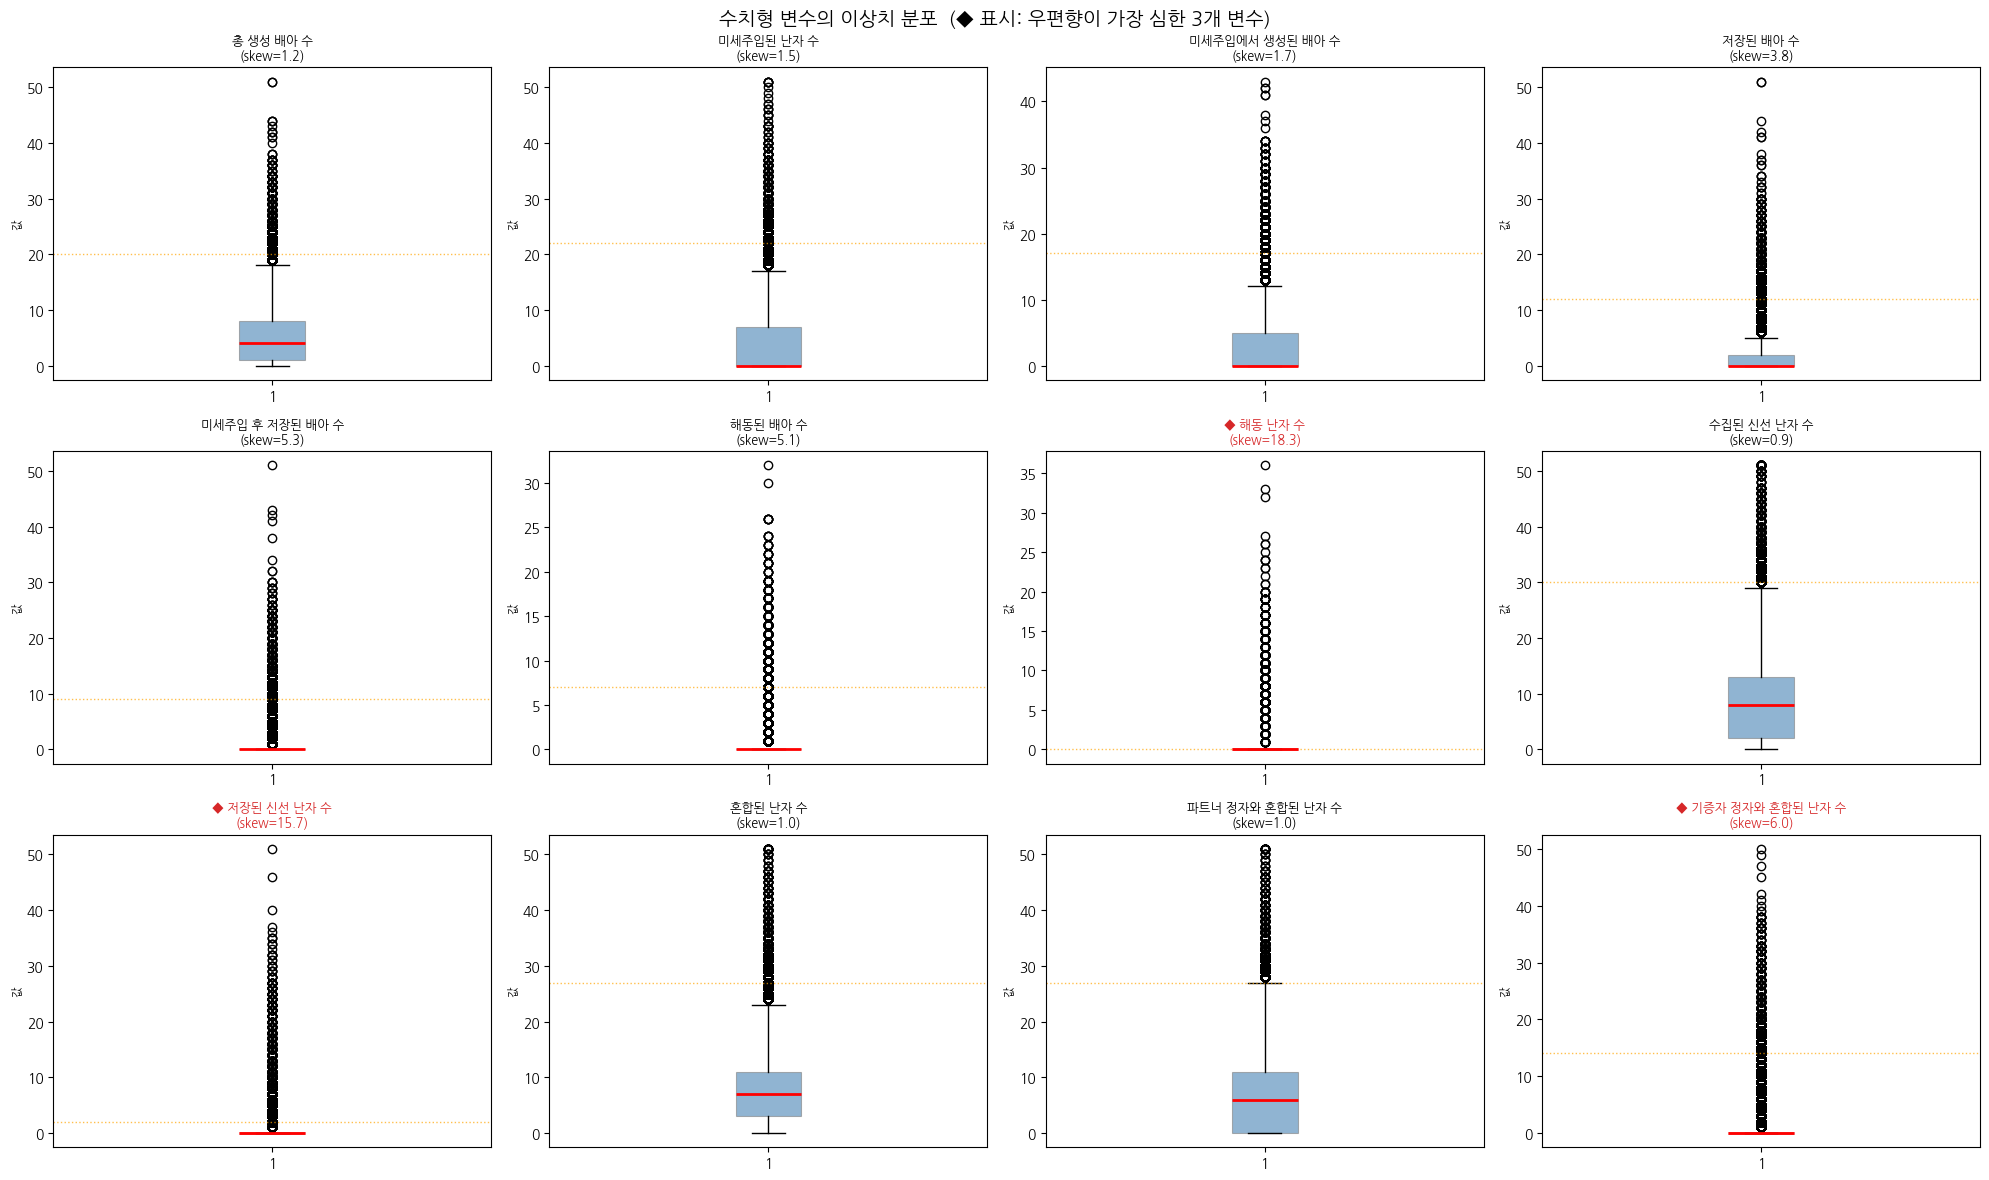


관찰: 모든 변수에서 박스(IQR)는 매우 좁고, 일부 점들이 박스의 수십 배 위에 흩어져 있습니다.
이러한 우편향 분포는 다음 셀의 로그 변환을 통해 어느 정도 완화될 수 있습니다.


In [ ]:
# ============================================================
# 수치형 변수의 이상치 분포
# ============================================================

outlier_cols = [
    '총 생성 배아 수', '미세주입된 난자 수', '미세주입에서 생성된 배아 수',
    '저장된 배아 수', '미세주입 후 저장된 배아 수', '해동된 배아 수',
    '해동 난자 수', '수집된 신선 난자 수', '저장된 신선 난자 수',
    '혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수'
]

# 우편향이 가장 심한 3개 변수를 사전에 확인하여 강조 표시 대상으로 지정합니다.
# 비대칭도(skewness)가 큰 순서대로 상위 3개를 선택합니다.
skewness = eda_df[outlier_cols].skew().sort_values(ascending=False)
top3_skewed = skewness.head(3).index.tolist()
print('우편향이 가장 심한 3개 변수 (skewness 기준)')
for col in top3_skewed:
    print(f'  {col}: skewness={skewness[col]:.2f}')
print()

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    is_top3 = col in top3_skewed

    # 강조 대상은 빨간 테두리, 일반은 회색 테두리
    box_color = '#FFB3B3' if is_top3 else 'steelblue'
    edge_color = '#D62728' if is_top3 else 'gray'
    edge_width = 2.0 if is_top3 else 0.8

    bp = axes[i].boxplot(
        eda_df[col].dropna(), vert=True, patch_artist=True,
        boxprops=dict(facecolor=box_color, alpha=0.6,
                      edgecolor=edge_color, linewidth=edge_width),
        medianprops=dict(color='red', linewidth=2),
    )

    title_color = '#D62728' if is_top3 else 'black'
    title_text = f'{col}\n(skew={skewness[col]:.1f})'
    if is_top3:
        title_text = '◆ ' + title_text
    axes[i].set_title(title_text, fontsize=9, color=title_color,
                       fontweight='bold' if is_top3 else 'normal')
    axes[i].set_ylabel('값', fontsize=8)

    # 99% 분위수 기준선 표시 (이상치 경계)
    p99 = eda_df[col].quantile(0.99)
    if not pd.isna(p99):
        axes[i].axhline(y=p99, color='orange', linestyle=':', linewidth=1, alpha=0.7)

plt.suptitle('수치형 변수의 이상치 분포  (◆ 표시: 우편향이 가장 심한 3개 변수)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print()
print('관찰: 모든 변수에서 박스(IQR)는 매우 좁고, 일부 점들이 박스의 수십 배 위에 흩어져 있습니다.')
print('이러한 우편향 분포는 다음 셀의 로그 변환을 통해 어느 정도 완화될 수 있습니다.')

### 추가 EDA 2 — 로그 변환 전후 분포 비교


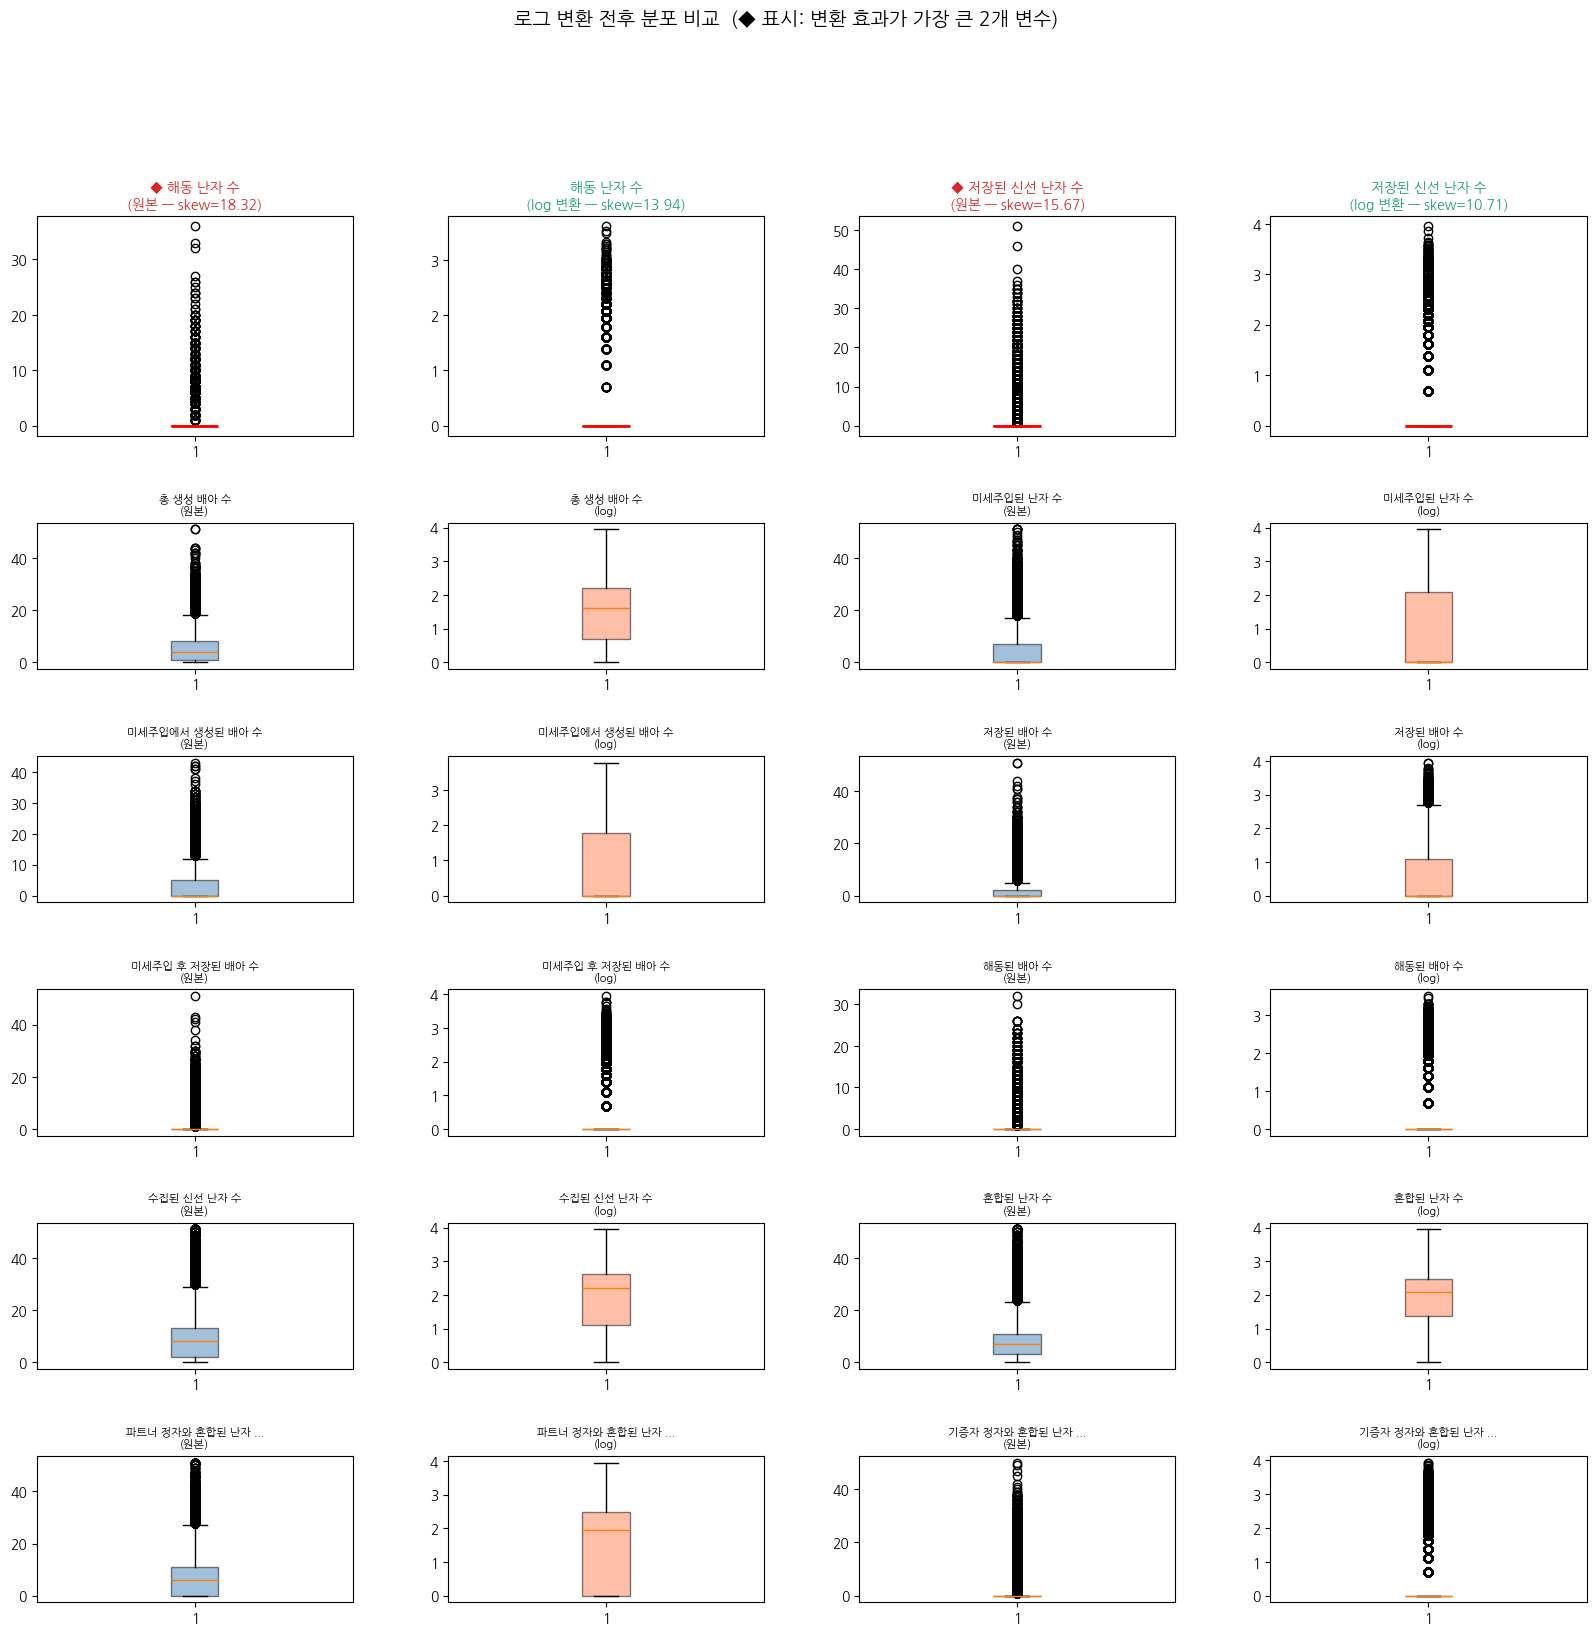


관찰: 로그 변환 후 박스플롯의 박스(IQR)가 그림 안에서 차지하는 비율이 늘어나
전체 데이터의 분포 형태를 한눈에 파악하기 수월해집니다.
해석: 트리 기반 모델은 단조 변환에 영향을 받지 않으므로 본 모델은 원본 그대로 사용하나,
선형 모델이나 신경망을 사용할 때는 이 변환이 의미 있는 차이를 만들 수 있습니다.


In [ ]:
# ============================================================
#  로그 변환 전후 분포 비교
# ============================================================

top2_skewed = top3_skewed[:2]

# 그림 구성: 위쪽 1행에 강조 변수 2개를 크게, 아래쪽 5행 4열에 나머지 10개를 작게
fig = plt.figure(figsize=(20, 18))
gs = fig.add_gridspec(6, 4, height_ratios=[1.5, 1, 1, 1, 1, 1], hspace=0.55, wspace=0.3)

# ------------------------------------------------------------
# 위쪽: 강조 변수 2개 (각각 원본/로그 한 쌍)
# ------------------------------------------------------------
for i, col in enumerate(top2_skewed):
    # 원본
    ax_orig = fig.add_subplot(gs[0, i*2])
    ax_orig.boxplot(eda_df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#FFB3B3', alpha=0.7,
                                  edgecolor='#D62728', linewidth=1.5),
                    medianprops=dict(color='red', linewidth=2))
    ax_orig.set_title(f'◆ {col}\n(원본 — skew={eda_df[col].skew():.2f})',
                       fontsize=10, color='#D62728', fontweight='bold')

    # 로그 변환
    ax_log = fig.add_subplot(gs[0, i*2 + 1])
    log_val = np.log1p(eda_df[col].dropna())
    ax_log.boxplot(log_val, patch_artist=True,
                   boxprops=dict(facecolor='#B3E8B3', alpha=0.7,
                                 edgecolor='#1D9E75', linewidth=1.5),
                   medianprops=dict(color='red', linewidth=2))
    ax_log.set_title(f'{col}\n(log 변환 — skew={log_val.skew():.2f})',
                      fontsize=10, color='#1D9E75', fontweight='bold')

# ------------------------------------------------------------
# 아래쪽: 나머지 변수 (압축 표시)
# ------------------------------------------------------------
remaining = [c for c in outlier_cols if c not in top2_skewed]
for i, col in enumerate(remaining):
    row = (i // 2) + 1
    col_pos = (i % 2) * 2

    ax1 = fig.add_subplot(gs[row, col_pos])
    ax1.boxplot(eda_df[col].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5))
    ax1.set_title(f'{col[:15]}...\n(원본)' if len(col) > 15 else f'{col}\n(원본)',
                   fontsize=8)

    ax2 = fig.add_subplot(gs[row, col_pos + 1])
    ax2.boxplot(np.log1p(eda_df[col].dropna()), patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.5))
    ax2.set_title(f'{col[:15]}...\n(log)' if len(col) > 15 else f'{col}\n(log)',
                   fontsize=8)

plt.suptitle('로그 변환 전후 분포 비교  (◆ 표시: 변환 효과가 가장 큰 2개 변수)',
             fontsize=14, fontweight='bold', y=0.995)
plt.show()
print()
print('관찰: 로그 변환 후 박스플롯의 박스(IQR)가 그림 안에서 차지하는 비율이 늘어나')
print('전체 데이터의 분포 형태를 한눈에 파악하기 수월해집니다.')
print('해석: 트리 기반 모델은 단조 변환에 영향을 받지 않으므로 본 모델은 원본 그대로 사용하나,')
print('선형 모델이나 신경망을 사용할 때는 이 변환이 의미 있는 차이를 만들 수 있습니다.')

### 추가 EDA 3 — 난자 출처별 임신 성공률 (자가 vs 기증)


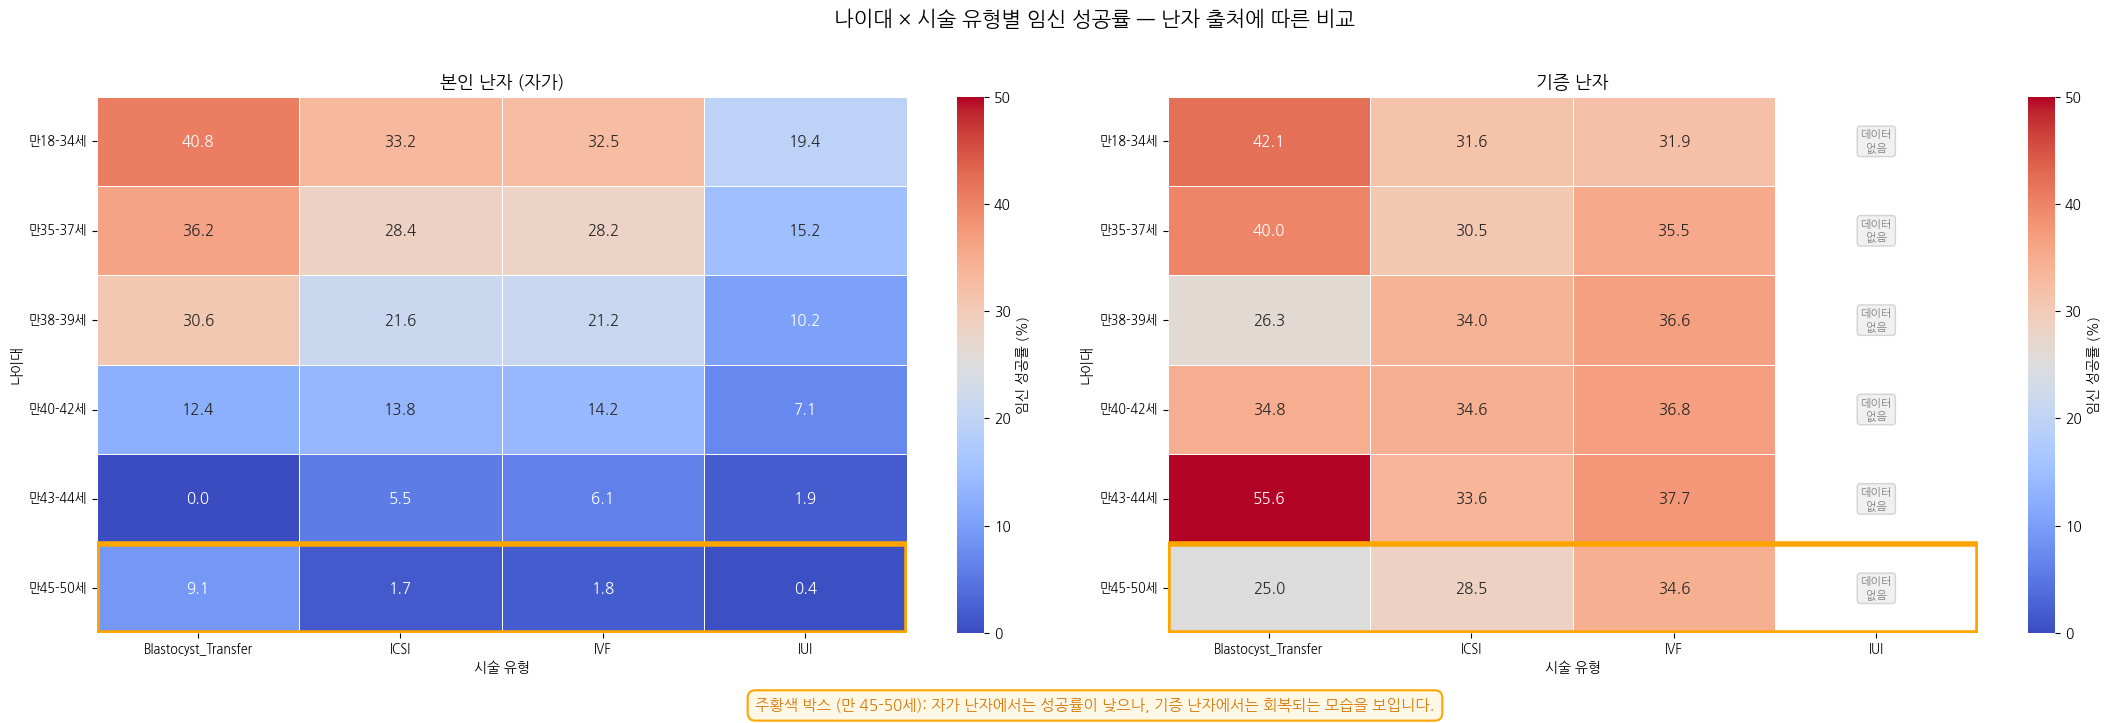


만 45-50세 그룹의 임신 성공률 비교
  자가 난자 사용: 2.6%
  기증 난자 사용: 29.2%
  차이:           +26.6%p

이 차이가 만 45-50세 구간 평균 성공률을 끌어올린 진짜 원인입니다.
모델 학습 시 자가난자×나이, 기증난자×나이 변수를 분리하여 만든 까닭이기도 합니다.


In [ ]:
# ============================================================
#  난자 출처별 임신 성공률 — 자가 vs 기증 [핵심 발견]
# ============================================================

age_order = ['만18-34세', '만35-37세', '만38-39세', '만40-42세', '만43-44세', '만45-50세']
treatment_order = ['Blastocyst_Transfer', 'ICSI', 'IVF', 'IUI']

fig, axes = plt.subplots(1, 2, figsize=(22, 7))

for ax, source, title in zip(
    axes,
    ['본인 제공', '기증 제공'],
    ['본인 난자 (자가)', '기증 난자']
):
    df_source = eda_df[
        (eda_df['시술 당시 나이'].isin(age_order)) &
        (eda_df['시술_분류_그룹'].isin(treatment_order)) &
        (eda_df['난자 출처'] == source)
    ]

    pivot = df_source.groupby(['시술 당시 나이', '시술_분류_그룹'])[TARGET].mean().unstack()
    pivot = pivot.reindex(age_order).reindex(columns=treatment_order)
    pivot_pct = (pivot * 100).round(1)
    mask = pivot_pct.isna()

    sns.heatmap(
        pivot_pct, annot=True, fmt='.1f', cmap='coolwarm',
        vmin=0, vmax=50, linewidths=0.5, linecolor='white',
        annot_kws={'size': 11, 'weight': 'bold'},
        cbar_kws={'label': '임신 성공률 (%)'},
        mask=mask, ax=ax
    )

    # 데이터 없음 표시
    for i in range(len(age_order)):
        for j in range(len(treatment_order)):
            if mask.iloc[i, j]:
                ax.text(j + 0.5, i + 0.5, '데이터\n없음',
                        ha='center', va='center', fontsize=8,
                        color='gray',
                        bbox=dict(boxstyle='round,pad=0.3',
                                  facecolor='#F0F0F0', edgecolor='lightgray'))

    # ★ 핵심 강조: 만 45-50세 행에 노란 박스
    from matplotlib.patches import Rectangle
    rect = Rectangle((0, 5), len(treatment_order), 1,
                     fill=False, edgecolor='#FFA500', linewidth=4, zorder=10)
    ax.add_patch(rect)

    ax.set_title(f'{title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('시술 유형', fontsize=10)
    ax.set_ylabel('나이대', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=9, rotation=0)

# 강조 안내 텍스트 (그림 사이)
fig.text(0.5, 0.02,
         '주황색 박스 (만 45-50세): 자가 난자에서는 성공률이 낮으나, 기증 난자에서는 회복되는 모습을 보입니다.',
         ha='center', fontsize=11, color='#D97706', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF8E7',
                   edgecolor='#FFA500', linewidth=1.5))

plt.suptitle('나이대 × 시술 유형별 임신 성공률 — 난자 출처에 따른 비교',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(bottom=0.13)
plt.show()

# 만 45-50세의 두 그룹 성공률을 출력하여 메시지를 정량화합니다.
own_4550 = eda_df[
    (eda_df['시술 당시 나이'] == '만45-50세') &
    (eda_df['난자 출처'] == '본인 제공')
][TARGET].mean() * 100
donor_4550 = eda_df[
    (eda_df['시술 당시 나이'] == '만45-50세') &
    (eda_df['난자 출처'] == '기증 제공')
][TARGET].mean() * 100

print()
print('만 45-50세 그룹의 임신 성공률 비교')
print(f'  자가 난자 사용: {own_4550:.1f}%')
print(f'  기증 난자 사용: {donor_4550:.1f}%')
print(f'  차이:           {donor_4550 - own_4550:+.1f}%p')
print()
print('이 차이가 만 45-50세 구간 평균 성공률을 끌어올린 진짜 원인입니다.')
print('모델 학습 시 자가난자×나이, 기증난자×나이 변수를 분리하여 만든 까닭이기도 합니다.')

### 추가 EDA 4 — 불임 원인별 임신 성공률 비교


성공률 격차가 가장 큰 불임 원인: 부부 부 불임 원인
  있음: 18.7%
  없음: 25.9%
  차이: -7.2%p



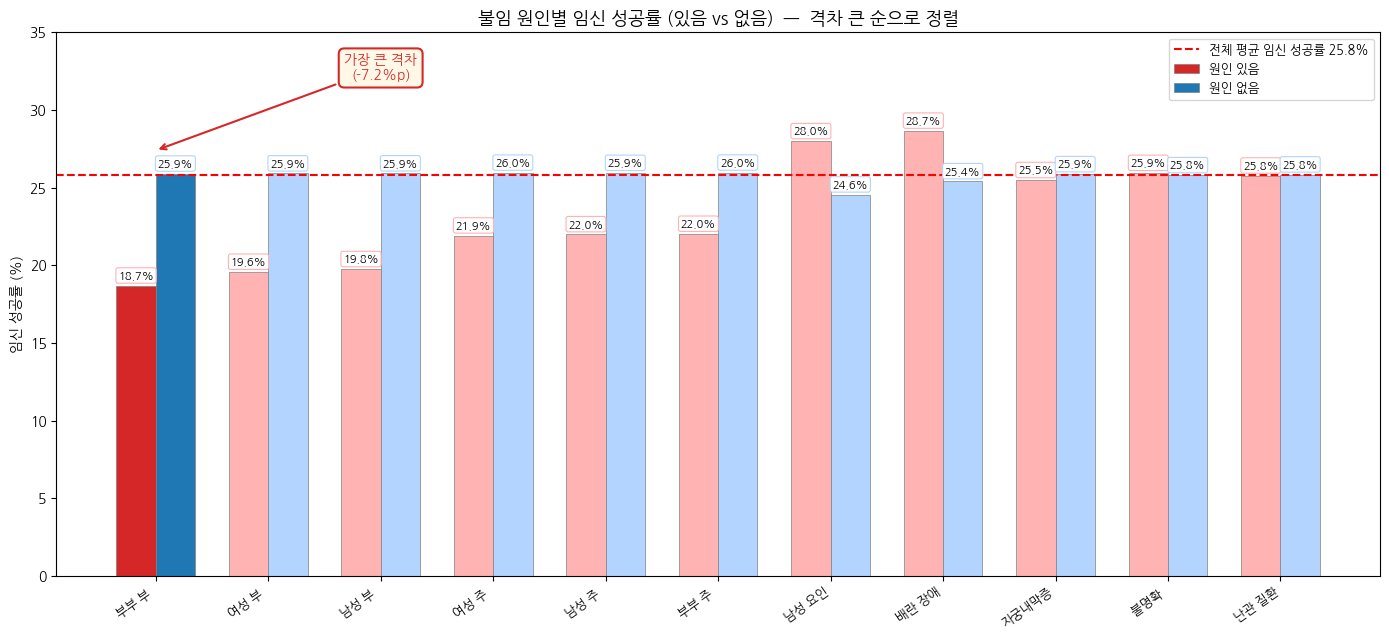


관찰: 원인의 종류에 따라 성공률 격차의 크기와 방향이 다릅니다.
해석: 단순히 "불임 원인이 있다"가 아니라, 어떤 원인인지가 결과에 더 중요합니다.
이러한 다양한 신호를 모델은 트리의 분기를 통해 자체적으로 학습합니다.


In [ ]:
# ============================================================
# 불임 원인별 임신 성공률 비교
# ============================================================

cause_cols = [
    '남성 주 불임 원인', '여성 주 불임 원인',
    '부부 주 불임 원인', '부부 부 불임 원인',
    '남성 부 불임 원인', '여성 부 불임 원인',
    '불임 원인 - 난관 질환', '불임 원인 - 남성 요인',
    '불임 원인 - 배란 장애', '불임 원인 - 자궁내막증',
    '불임 원인 - 자궁내막 또는 자궁 내 유착',
    '불명확 불임 원인'
]
# 데이터에 실제 존재하는 컬럼만 선택
cause_cols = [c for c in cause_cols if c in eda_df.columns]

# 각 원인별로 '있음', '없음' 그룹의 성공률 계산
success_rates = {}
for col in cause_cols:
    success_rates[col] = {
        '있음': eda_df[eda_df[col] == 1][TARGET].mean(),
        '없음': eda_df[eda_df[col] == 0][TARGET].mean(),
    }

# 격차(있음 - 없음의 차이)가 큰 순으로 정렬하면 메시지가 더 잘 보입니다.
gap = {c: success_rates[c]['있음'] - success_rates[c]['없음'] for c in cause_cols}
sorted_cols = sorted(cause_cols, key=lambda c: abs(gap[c]), reverse=True)

# 가장 큰 격차를 보이는 변수 (강조 대상)
top_cause = sorted_cols[0]
print(f'성공률 격차가 가장 큰 불임 원인: {top_cause}')
print(f'  있음: {success_rates[top_cause]["있음"]*100:.1f}%')
print(f'  없음: {success_rates[top_cause]["없음"]*100:.1f}%')
print(f'  차이: {gap[top_cause]*100:+.1f}%p')
print()

fig, ax = plt.subplots(figsize=(14, 6.5))

cols = sorted_cols
있음 = [success_rates[c]['있음'] * 100 for c in cols]
없음 = [success_rates[c]['없음'] * 100 for c in cols]

x = np.arange(len(cols))
width = 0.35

# 강조: 격차가 가장 큰 원인의 막대를 진한 색으로 표시
top_idx = 0  # 정렬되어 있으므로 첫 번째가 가장 큰 격차
bar_colors_있음 = ['#D62728' if i == top_idx else '#FFB3B3' for i in range(len(cols))]
bar_colors_없음 = ['#1F77B4' if i == top_idx else '#B3D4FF' for i in range(len(cols))]

bars1 = ax.bar(x - width/2, 있음, width, label='원인 있음',
                color=bar_colors_있음, edgecolor='gray', linewidth=0.5)
bars2 = ax.bar(x + width/2, 없음, width, label='원인 없음',
                color=bar_colors_없음, edgecolor='gray', linewidth=0.5)

# 평균선
mean_rate = eda_df[TARGET].mean() * 100
ax.axhline(y=mean_rate, color='red', linestyle='--', linewidth=1.5,
           label=f'전체 평균 임신 성공률 {mean_rate:.1f}%')

ax.set_xticks(x)
labels = [c.replace('불임 원인 - ', '').replace('불임 원인', '') for c in cols]
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('임신 성공률 (%)')
ax.set_ylim(0, 35)
ax.set_title('불임 원인별 임신 성공률 (있음 vs 없음)  —  격차 큰 순으로 정렬',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)

# 막대 위 수치 표시
for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor='#FFB3B3', linewidth=0.8))
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor='#B3D4FF', linewidth=0.8))

# 강조 화살표 + 설명 박스
ax.annotate(
    f'가장 큰 격차\n({gap[top_cause]*100:+.1f}%p)',
    xy=(0, max(있음[0], 없음[0]) + 1.5),
    xytext=(2, 32),
    fontsize=10, fontweight='bold', color='#D62728',
    ha='center',
    arrowprops=dict(arrowstyle='->', color='#D62728', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF8E7',
              edgecolor='#D62728', linewidth=1.5)
)

plt.tight_layout()
plt.show()
print()
print('관찰: 원인의 종류에 따라 성공률 격차의 크기와 방향이 다릅니다.')
print('해석: 단순히 "불임 원인이 있다"가 아니라, 어떤 원인인지가 결과에 더 중요합니다.')
print('이러한 다양한 신호를 모델은 트리의 분기를 통해 자체적으로 학습합니다.')

### 추가 EDA 5 — 배아·난자 수치(log) 분포 (성공 vs 실패)


성공 그룹과 실패 그룹의 중앙값 차이가 가장 큰 변수: 미세주입에서 생성된 배아 수
  차이: +0.693 (log 단위)



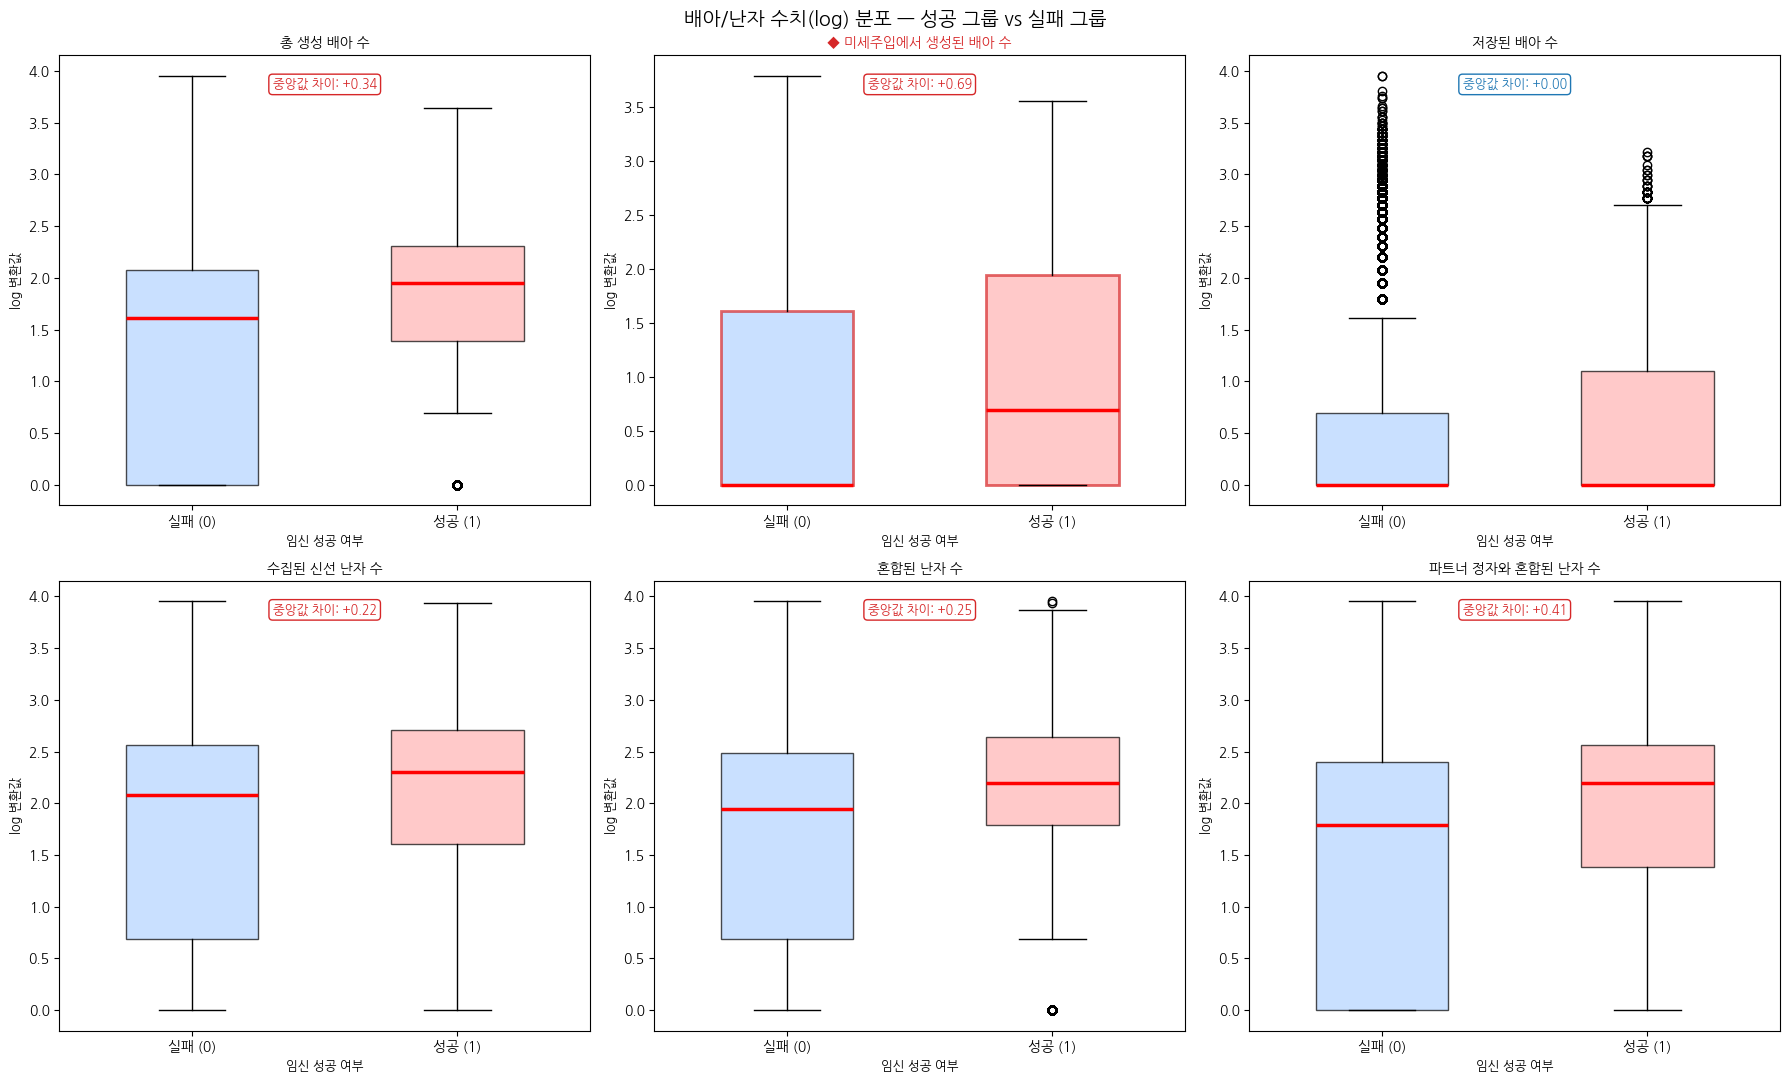


관찰: 성공 그룹의 중앙값이 실패 그룹보다 일관되게 위쪽에 위치합니다.
해석: 배아와 난자가 더 많이 생성되었다는 것은 그 자체로 좋은 시술 환경을 의미합니다.
이 신호들은 로그 변환을 거치지 않은 원본 그대로도 트리 모델이 충분히 학습할 수 있습니다.


In [ ]:
# ============================================================
# (추가 EDA 5) 배아/난자 수치(log) 분포 — 성공 그룹 vs 실패 그룹
# ============================================================

log_cols = [
    '총 생성 배아 수', '미세주입에서 생성된 배아 수', '저장된 배아 수',
    '수집된 신선 난자 수', '혼합된 난자 수', '파트너 정자와 혼합된 난자 수'
]

# 임시로 로그 변환 컬럼 생성 (시각화 전용, eda_df에 추가)
for col in log_cols:
    eda_df[col + '_log'] = np.log1p(eda_df[col].fillna(0))

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

# 각 변수에서 성공/실패 그룹 중앙값 차이를 사전 계산
median_diffs = []
for col in log_cols:
    log_col = col + '_log'
    med_fail = eda_df[eda_df[TARGET] == 0][log_col].median()
    med_success = eda_df[eda_df[TARGET] == 1][log_col].median()
    median_diffs.append((col, med_success - med_fail))

# 격차가 가장 큰 변수를 강조 대상으로 지정
median_diffs.sort(key=lambda x: abs(x[1]), reverse=True)
top_var = median_diffs[0][0]
print(f'성공 그룹과 실패 그룹의 중앙값 차이가 가장 큰 변수: {top_var}')
print(f'  차이: {median_diffs[0][1]:+.3f} (log 단위)')
print()

for i, col in enumerate(log_cols):
    log_col = col + '_log'
    is_top = col == top_var

    # 성공/실패 그룹 분리
    data_fail = eda_df[eda_df[TARGET] == 0][log_col].dropna()
    data_success = eda_df[eda_df[TARGET] == 1][log_col].dropna()

    bp = axes[i].boxplot(
        [data_fail, data_success],
        labels=['실패 (0)', '성공 (1)'],
        patch_artist=True,
        widths=0.5,
        boxprops=dict(facecolor='#B3D4FF', alpha=0.7),
        medianprops=dict(color='red', linewidth=2.5),
    )
    # 성공 그룹 박스만 색상 변경
    bp['boxes'][1].set_facecolor('#FFB3B3')

    # 강조 변수의 외곽선 두껍게
    if is_top:
        for box in bp['boxes']:
            box.set_edgecolor('#D62728')
            box.set_linewidth(2)

    title_text = f'◆ {col}' if is_top else col
    title_color = '#D62728' if is_top else 'black'
    axes[i].set_title(title_text, fontsize=10, color=title_color,
                       fontweight='bold' if is_top else 'normal')
    axes[i].set_ylabel('log 변환값', fontsize=9)
    axes[i].set_xlabel('임신 성공 여부', fontsize=9)

    # 중앙값 차이를 텍스트로 표시
    med_diff = data_success.median() - data_fail.median()
    color_diff = '#D62728' if med_diff > 0 else '#1F77B4'
    axes[i].text(0.5, 0.95,
                  f'중앙값 차이: {med_diff:+.2f}',
                  transform=axes[i].transAxes,
                  ha='center', va='top', fontsize=9, fontweight='bold',
                  color=color_diff,
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                            edgecolor=color_diff, linewidth=1))

plt.suptitle('배아/난자 수치(log) 분포 — 성공 그룹 vs 실패 그룹',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 임시 컬럼 정리
eda_df.drop(columns=[c + '_log' for c in log_cols], inplace=True)

print()
print('관찰: 성공 그룹의 중앙값이 실패 그룹보다 일관되게 위쪽에 위치합니다.')
print('해석: 배아와 난자가 더 많이 생성되었다는 것은 그 자체로 좋은 시술 환경을 의미합니다.')
print('이 신호들은 로그 변환을 거치지 않은 원본 그대로도 트리 모델이 충분히 학습할 수 있습니다.')

### 추가 EDA 6 — 배아 종류별 임신 성공률 (해동/동결/신선)


평균 대비 격차가 가장 큰 그룹: 동결 배아 사용
  미사용: 26.8% / 사용: 22.9%
  차이:   -3.8%p



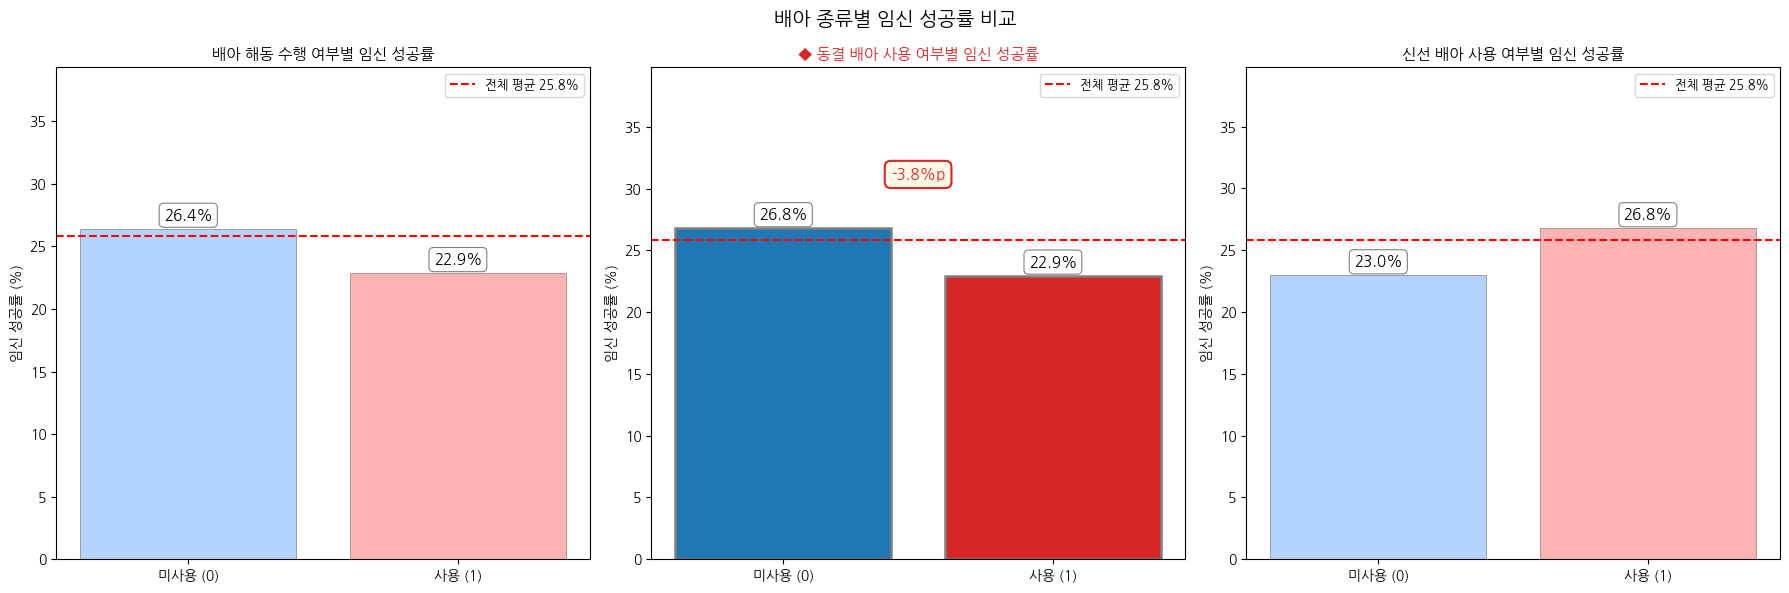


관찰: 동결 배아 사용 여부가 임신 성공률에 가장 큰 영향을 미치는 것으로 보입니다.
해석: 자궁 내막 상태가 양호한 주기를 골라 이식하는 임상 전략의 효과로 해석됩니다.


In [ ]:
# ============================================================
#  배아 종류별 임신 성공률 — 해동/동결/신선
# ============================================================

mean_rate = eda_df[TARGET].mean() * 100

# 강조 대상 사전 계산: 평균 대비 격차가 가장 큰 그룹
groups = ['배아해동_수행', '동결 배아 사용 여부', '신선 배아 사용 여부']
group_labels = ['배아 해동 수행', '동결 배아 사용', '신선 배아 사용']

# 시각화에 필요한 컬럼이 eda_df에 있는지 확인
# 배아해동_수행은 원본 컬럼이 아니므로 임시로 생성합니다.
if '배아해동_수행' not in eda_df.columns:
    if '해동된 배아 수' in eda_df.columns:
        eda_df['배아해동_수행'] = (eda_df['해동된 배아 수'].fillna(0) > 0).astype(int)
    else:
        eda_df['배아해동_수행'] = 0

# 그룹별 성공률
group_rates = []
for col, label in zip(groups, group_labels):
    if col in eda_df.columns:
        rate_0 = eda_df[eda_df[col] == 0][TARGET].mean() * 100
        rate_1 = eda_df[eda_df[col] == 1][TARGET].mean() * 100
        group_rates.append({
            'col': col, 'label': label,
            'rate_0': rate_0, 'rate_1': rate_1,
            'gap': abs(rate_1 - rate_0)
        })

# 격차가 가장 큰 그룹을 강조 대상으로
top_group = max(group_rates, key=lambda x: x['gap'])
print(f'평균 대비 격차가 가장 큰 그룹: {top_group["label"]}')
print(f'  미사용: {top_group["rate_0"]:.1f}% / 사용: {top_group["rate_1"]:.1f}%')
print(f'  차이:   {top_group["rate_1"] - top_group["rate_0"]:+.1f}%p')
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, info in enumerate(group_rates):
    is_top = info['col'] == top_group['col']

    rates = [info['rate_0'], info['rate_1']]
    labels = ['미사용 (0)', '사용 (1)']

    # 강조 대상은 진한 색, 나머지는 연한 색
    if is_top:
        colors = ['#1F77B4', '#D62728']
        edge_width = 1.8
    else:
        colors = ['#B3D4FF', '#FFB3B3']
        edge_width = 0.5

    bars = axes[i].bar(labels, rates,
                        color=colors, edgecolor='gray', linewidth=edge_width)

    title_text = f'◆ {info["label"]}' if is_top else info['label']
    title_color = '#D62728' if is_top else 'black'
    axes[i].set_title(f'{title_text} 여부별 임신 성공률',
                       fontsize=11, color=title_color,
                       fontweight='bold' if is_top else 'normal')
    axes[i].set_ylabel('임신 성공률 (%)')
    axes[i].set_ylim(0, max(rates) * 1.3 + 5)
    axes[i].axhline(y=mean_rate, color='red', linestyle='--',
                     label=f'전체 평균 {mean_rate:.1f}%')
    axes[i].legend(fontsize=9)

    # 막대 위 수치 표시
    for bar, val in zip(bars, rates):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                      f'{val:.1f}%', ha='center', va='bottom', fontsize=11,
                      fontweight='bold' if is_top else 'normal',
                      bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                                edgecolor='gray', linewidth=0.8))

    # 강조 대상에는 격차 화살표
    if is_top:
        axes[i].annotate(
            f'{info["rate_1"] - info["rate_0"]:+.1f}%p',
            xy=(0.5, max(rates) + 1.5),
            xytext=(0.5, max(rates) + 4),
            ha='center', fontsize=11, fontweight='bold', color='#D62728',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF8E7',
                      edgecolor='#D62728', linewidth=1.5)
        )

plt.suptitle('배아 종류별 임신 성공률 비교',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 임시 컬럼 정리
if '배아해동_수행' in eda_df.columns and '해동된 배아 수' in eda_df.columns:
    eda_df.drop(columns=['배아해동_수행'], inplace=True)

print()
print('관찰: 동결 배아 사용 여부가 임신 성공률에 가장 큰 영향을 미치는 것으로 보입니다.')
print('해석: 자궁 내막 상태가 양호한 주기를 골라 이식하는 임상 전략의 효과로 해석됩니다.')

### 추가 EDA 7 — 나이대와 과거 시술 횟수의 교차 분석


나이대별 1-2회 시술 그룹과 0회 시술 그룹의 성공률 차이
  만18-34세: 0회 34.0% → 1-2회 31.0%  (↓ 3.1%p)
  만35-37세: 0회 30.2% → 1-2회 26.8%  (↓ 3.4%p)
  만38-39세: 0회 23.5% → 1-2회 21.1%  (↓ 2.4%p)
  만40-42세: 0회 16.6% → 1-2회 15.7%  (↓ 1.0%p)
  만43-44세: 0회 11.3% → 1-2회 12.0%  (↑ 0.7%p)
  만45-50세: 0회 18.6% → 1-2회 16.3%  (↓ 2.3%p)



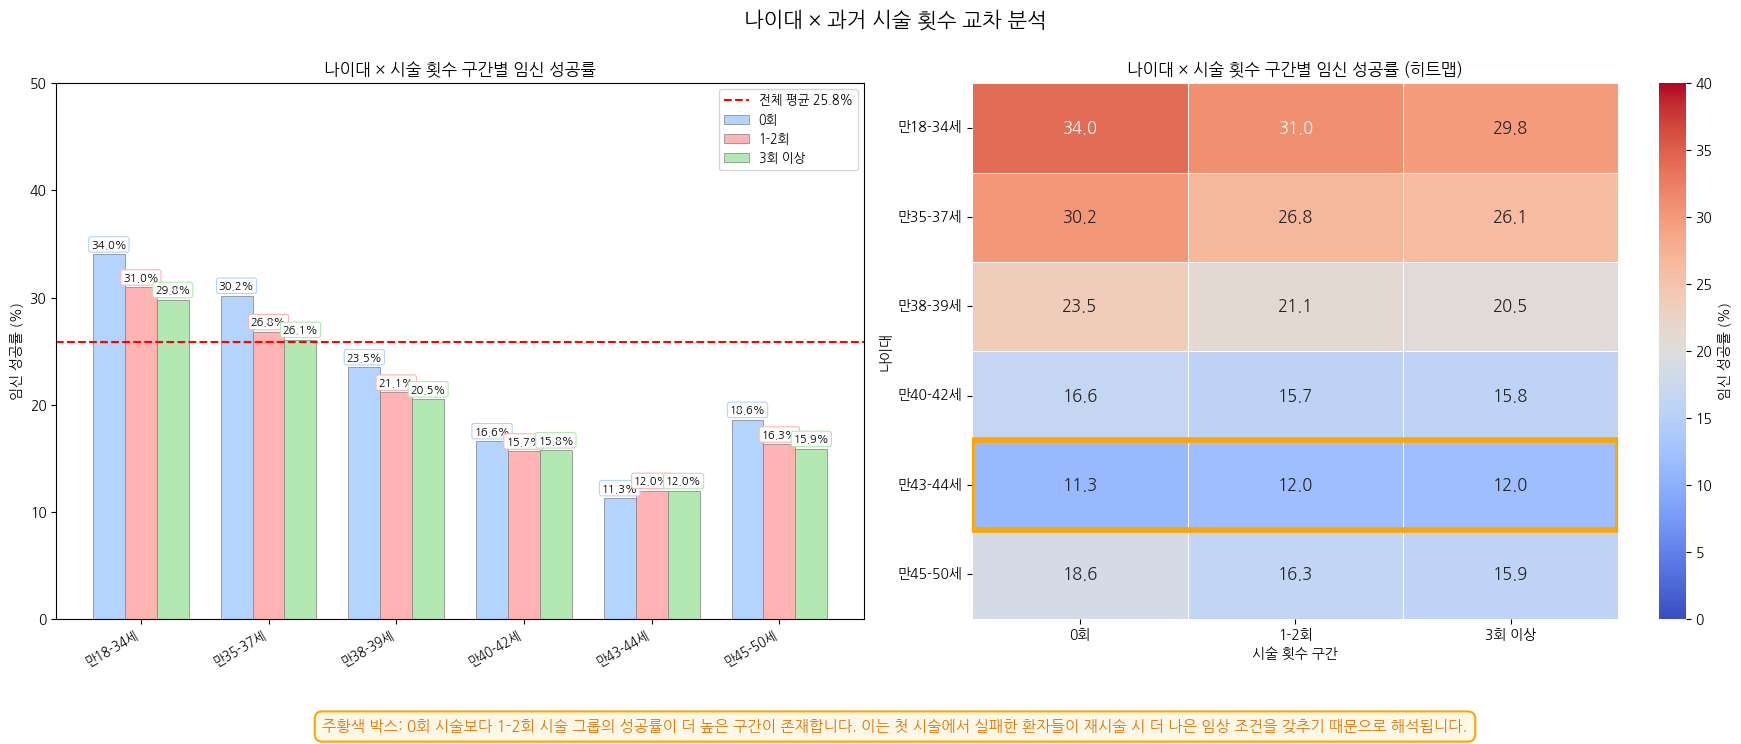


관찰: 직관과 달리 일부 나이대에서는 과거 1-2회 시술 그룹의 성공률이 첫 시술보다 높습니다.
해석: 첫 시술 실패 후 진단·전처치가 보강되어 두 번째 시도에서 더 좋은 조건을 갖추는
임상 패턴이 반영된 결과로 볼 수 있습니다.
한편 3회 이상 시술 그룹은 모든 나이대에서 성공률이 크게 떨어집니다.
반복 실패가 누적될수록 더 까다로운 케이스가 모이는 영향으로 보입니다.


In [ ]:
# ============================================================
# 나이대와 과거 시술 횟수의 교차 분석
# ============================================================

def parse_count_eda(s):
    return s.astype(str).str.extract(r'(\d+)')[0].fillna(0).astype(int)

eda_df['총_시술_횟수_int'] = parse_count_eda(eda_df['총 시술 횟수'])
eda_df['시술횟수_구간'] = pd.cut(
    eda_df['총_시술_횟수_int'],
    bins=[-1, 0, 2, 100],
    labels=['0회', '1-2회', '3회 이상']
)

age_order = ['만18-34세', '만35-37세', '만38-39세', '만40-42세', '만43-44세', '만45-50세']

# 나이대 × 시술 횟수 교차표
pivot = eda_df[eda_df['시술 당시 나이'].isin(age_order)].groupby(
    ['시술 당시 나이', '시술횟수_구간'], observed=True
)[TARGET].mean().unstack() * 100
pivot = pivot.reindex(age_order)

# 핵심 발견 사전 계산: 첫 시술(0회) 그룹과 1-2회 그룹의 차이가 큰 나이대 찾기
gaps = pivot['1-2회'] - pivot['0회']
print('나이대별 1-2회 시술 그룹과 0회 시술 그룹의 성공률 차이')
for age in age_order:
    if age in pivot.index:
        diff = gaps[age]
        if not pd.isna(diff):
            arrow = '↑' if diff > 0 else '↓'
            print(f'  {age}: 0회 {pivot.loc[age, "0회"]:.1f}% → 1-2회 {pivot.loc[age, "1-2회"]:.1f}%  ({arrow} {abs(diff):.1f}%p)')
print()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ------------------------------------------------------------
# (왼쪽) 막대 그래프
# ------------------------------------------------------------
x = np.arange(len(age_order))
width = 0.25
colors = ['#B3D4FF', '#FFB3B3', '#B3E8B3']
labels = ['0회', '1-2회', '3회 이상']

for j, (col, color) in enumerate(zip(labels, colors)):
    vals = pivot[col].values
    bars = axes[0].bar(x + (j-1)*width, vals, width,
                        label=col, color=color, edgecolor='gray', linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        if not pd.isna(h) and h > 0:
            axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.4,
                          f'{h:.1f}%', ha='center', va='bottom', fontsize=8,
                          bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                    edgecolor=color, linewidth=0.8))

axes[0].set_xticks(x)
axes[0].set_xticklabels(age_order, rotation=30, ha='right', fontsize=9)
axes[0].set_title('나이대 × 시술 횟수 구간별 임신 성공률', fontsize=12, fontweight='bold')
axes[0].set_ylabel('임신 성공률 (%)')
axes[0].set_ylim(0, 50)
axes[0].axhline(y=eda_df[TARGET].mean()*100, color='red', linestyle='--',
                 label=f'전체 평균 {eda_df[TARGET].mean()*100:.1f}%')
axes[0].legend(loc='upper right', fontsize=9)

# ------------------------------------------------------------
# (오른쪽) 히트맵 — 한눈에 보기 쉽게
# ------------------------------------------------------------
sns.heatmap(
    pivot.round(1), annot=True, fmt='.1f', cmap='coolwarm',
    vmin=0, vmax=40, linewidths=0.5, linecolor='white',
    annot_kws={'size': 12, 'weight': 'bold'},
    cbar_kws={'label': '임신 성공률 (%)'},
    ax=axes[1]
)
axes[1].set_title('나이대 × 시술 횟수 구간별 임신 성공률 (히트맵)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('시술 횟수 구간', fontsize=10)
axes[1].set_ylabel('나이대', fontsize=10)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=10)

# 강조: 가장 큰 양의 격차를 보이는 행에 노란 박스
from matplotlib.patches import Rectangle
positive_gap_ages = gaps[gaps > 0].sort_values(ascending=False)
if len(positive_gap_ages) > 0:
    top_age_for_gap = positive_gap_ages.index[0]
    top_age_idx = age_order.index(top_age_for_gap)
    rect = Rectangle((0, top_age_idx), 3, 1, fill=False,
                     edgecolor='#FFA500', linewidth=4, zorder=10)
    axes[1].add_patch(rect)

plt.suptitle('나이대 × 과거 시술 횟수 교차 분석',
             fontsize=15, fontweight='bold', y=1.00)

# 핵심 발견 텍스트 박스 (그림 아래)
fig.text(0.5, -0.03,
         f'주황색 박스: 0회 시술보다 1-2회 시술 그룹의 성공률이 더 높은 구간이 존재합니다. '
         f'이는 첫 시술에서 실패한 환자들이 재시술 시 더 나은 임상 조건을 갖추기 때문으로 해석됩니다.',
         ha='center', fontsize=11, color='#D97706', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF8E7',
                   edgecolor='#FFA500', linewidth=1.5))

plt.tight_layout()
plt.subplots_adjust(bottom=0.13)
plt.show()

# 임시 컬럼 정리
eda_df.drop(columns=['총_시술_횟수_int', '시술횟수_구간'], inplace=True, errors='ignore')

print()
print('관찰: 직관과 달리 일부 나이대에서는 과거 1-2회 시술 그룹의 성공률이 첫 시술보다 높습니다.')
print('해석: 첫 시술 실패 후 진단·전처치가 보강되어 두 번째 시도에서 더 좋은 조건을 갖추는')
print('임상 패턴이 반영된 결과로 볼 수 있습니다.')
print('한편 3회 이상 시술 그룹은 모든 나이대에서 성공률이 크게 떨어집니다.')
print('반복 실패가 누적될수록 더 까다로운 케이스가 모이는 영향으로 보입니다.')

### 추가 EDA 8 — 주요 연속형 변수의 KDE 페어플롯

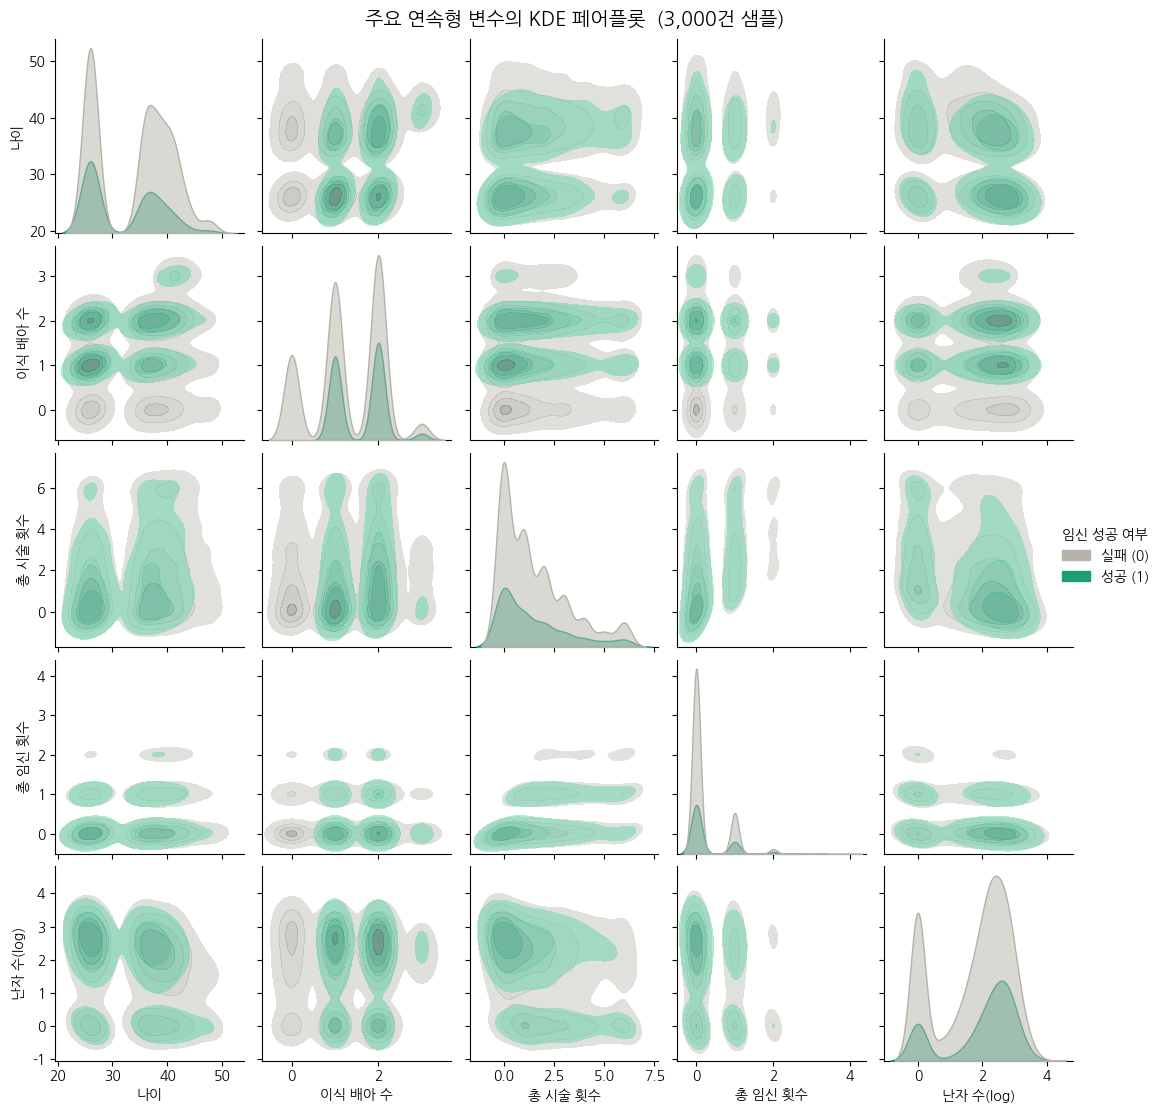


관찰 포인트
  - 대각선의 단변량 KDE: 두 그룹의 분포 봉우리 위치가 다른 변수가 좋은 신호입니다.
  - 비대각선의 결합 KDE: 두 색의 영역이 분리되어 보일수록 두 변수 조합이 결과를 잘 구분합니다.
  - 나이와 이식 배아 수의 조합에서 두 그룹의 분포가 뚜렷이 어긋난 모습을 확인할 수 있습니다.


In [ ]:
# ============================================================
# (추가 EDA 8) 주요 연속형 변수의 KDE 페어플롯
# ============================================================

def parse_count_for_kde(s):
    return s.astype(str).str.extract(r'(\d+)')[0].fillna(0).astype(int).clip(upper=10)

eda_df['_나이_수치_kde'] = eda_df['시술 당시 나이'].map(
    lambda x: age_info_eda.get(x, {'val': np.nan})['val'])
eda_df['_총_시술_kde'] = parse_count_for_kde(eda_df['총 시술 횟수'])
eda_df['_총_임신_kde'] = parse_count_for_kde(eda_df['총 임신 횟수'])
eda_df['_난자수_log_kde'] = np.log1p(eda_df['수집된 신선 난자 수'].fillna(0))

cont_cols = [
    '_나이_수치_kde',
    '이식된 배아 수',
    '_총_시술_kde',
    '_총_임신_kde',
    '_난자수_log_kde',
    TARGET,
]

# 페어플롯은 데이터가 많으면 매우 느려지므로 무작위로 3000개를 샘플링합니다.
# 시각화 전용이며 모델에는 영향을 주지 않습니다.
sample_df = eda_df[cont_cols].dropna().sample(n=min(3000, len(eda_df)), random_state=42)

# 컬럼명을 보기 좋게 변경 (그림 라벨용)
display_names = {
    '_나이_수치_kde': '나이',
    '이식된 배아 수': '이식 배아 수',
    '_총_시술_kde': '총 시술 횟수',
    '_총_임신_kde': '총 임신 횟수',
    '_난자수_log_kde': '난자 수(log)',
    TARGET: '임신 성공',
}
sample_df = sample_df.rename(columns=display_names)

g = sns.pairplot(
    sample_df,
    hue='임신 성공',
    palette={0: '#B4B2A9', 1: '#1D9E75'},
    kind='kde',
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 'fill': True, 'levels': 5},
    diag_kws={'fill': True, 'alpha': 0.5},
    height=2.2,
    aspect=1.0,
)

# 범례 라벨 한글화
if g.legend is not None:
    g.legend.set_title('임신 성공 여부')
    legend_texts = list(g.legend.texts)
    new_labels = ['실패 (0)', '성공 (1)']
    for t, label in zip(legend_texts, new_labels):
        t.set_text(label)

g.fig.suptitle('주요 연속형 변수의 KDE 페어플롯  (3,000건 샘플)',
                fontsize=14, fontweight='bold', y=1.01)

plt.show()

# 임시 컬럼 정리
eda_df.drop(columns=['_나이_수치_kde', '_총_시술_kde', '_총_임신_kde', '_난자수_log_kde'],
             inplace=True, errors='ignore')

print()
print('관찰 포인트')
print('  - 대각선의 단변량 KDE: 두 그룹의 분포 봉우리 위치가 다른 변수가 좋은 신호입니다.')
print('  - 비대각선의 결합 KDE: 두 색의 영역이 분리되어 보일수록 두 변수 조합이 결과를 잘 구분합니다.')
print('  - 나이와 이식 배아 수의 조합에서 두 그룹의 분포가 뚜렷이 어긋난 모습을 확인할 수 있습니다.')

---
## Part 2. 전처리 및 피처 엔지니어링


In [ ]:
# 전처리 상수 (COLS_TO_DROP, AGE_INFO 등)와 함수(engineer_features, build_features)는
# src/preprocessing.py 로 이동하였습니다.
# preprocess() 호출 한 줄로 전체 파이프라인이 실행됩니다.

In [ ]:
# 전처리 함수 정의는 src/preprocessing.py 를 참고하세요.
# engineer_features(), encode_multilabel(), preprocess_missing(), build_features()

In [ ]:
# ============================================================
# 전처리 실행
# ============================================================
X, y, X_test, scale_pos_weight = preprocess(df_raw, df_test_raw)
print(f'X: {X.shape}, y: {y.shape}, X_test: {X_test.shape}')

In [ ]:
# ============================================================
# 팀원 피처 5개 추가 (X와 X_test 모두에 동일하게 적용)
# ============================================================
# 피처 정의는 src/features.py 를 참고하세요.

X      = add_team_features(X)
X_test = add_team_features(X_test)
X_test = align_team_feature_categories(X, X_test)

print(f'팀원 피처 추가 완료: {X.shape[1]}개 피처')
print('추가된 피처:', ['배반포_5일차_이식', '젊은_고효율_이식', '이식경과일_구간', '동결_기증_복합', '고령_반복시술'])

---
##  Part 3. 모델 학습 및 검증


In [ ]:
# 학습 함수 정의는 src/model.py 를 참고하세요.
# run_lgbm_oof(), run_catboost_oof(), to_rank(), weighted_ensemble()

In [ ]:
# ============================================================
# LightGBM 하이퍼파라미터 설정
# ============================================================
# 파라미터 정의는 src/model.py 를 참고하세요.
# v4_params   : Optuna 탐색 최종 파라미터 (LB 0.74191)
# day45_params: 보수적 파라미터 (76개 피처 환경에서 탐색)

if USE_DAY45_PARAMS:
    best_params = day45_params
    print('day4_5 파라미터를 사용합니다 (참고용 비교 실험).')
    print('  주의: 76개 피처 환경에서 탐색된 값이라 본 환경의 결과는 다를 수 있습니다.')
else:
    best_params = v4_params
    print('v4 파라미터를 사용합니다 (LB 0.74191 기록 파라미터).')

lgbm_params = {**best_params, 'n_estimators': 3000}

print()
print('적용 파라미터')
for k, v in best_params.items():
    print(f'  {k:25s}: {v}')

In [ ]:
# ============================================================
# LightGBM 학습 (K-Fold OOF)
# ============================================================

print('=' * 55)
print(f'  LightGBM Stratified {N_SPLITS}-Fold OOF 학습')
print('=' * 55)

lgbm_models, lgbm_oof, lgbm_test, lgbm_auc = run_lgbm_oof(
    X, y, X_test, lgbm_params, n_splits=N_SPLITS, tag='lgbm'
)

  LightGBM Stratified 25-Fold OOF 학습
  [lgbm] Fold 1/25: AUC=0.7431  iter=202
[500]	valid_0's auc: 0.747008
  [lgbm] Fold 2/25: AUC=0.7472  iter=440
  [lgbm] Fold 3/25: AUC=0.7330  iter=155
[500]	valid_0's auc: 0.732877
  [lgbm] Fold 4/25: AUC=0.7330  iter=442
  [lgbm] Fold 5/25: AUC=0.7354  iter=207
[500]	valid_0's auc: 0.735454
  [lgbm] Fold 6/25: AUC=0.7357  iter=612
  [lgbm] Fold 7/25: AUC=0.7380  iter=368
[500]	valid_0's auc: 0.74665
  [lgbm] Fold 8/25: AUC=0.7468  iter=589
  [lgbm] Fold 9/25: AUC=0.7440  iter=292
[500]	valid_0's auc: 0.752413
  [lgbm] Fold 10/25: AUC=0.7526  iter=419
  [lgbm] Fold 11/25: AUC=0.7398  iter=264
[500]	valid_0's auc: 0.748118
  [lgbm] Fold 12/25: AUC=0.7482  iter=443
[500]	valid_0's auc: 0.739959
  [lgbm] Fold 13/25: AUC=0.7401  iter=526
[500]	valid_0's auc: 0.735102
  [lgbm] Fold 14/25: AUC=0.7353  iter=416
  [lgbm] Fold 15/25: AUC=0.7409  iter=396
[500]	valid_0's auc: 0.743574
  [lgbm] Fold 16/25: AUC=0.7437  iter=555
  [lgbm] Fold 17/25: AUC=0.7352

In [ ]:
# ============================================================
# CatBoost 학습 (K-Fold OOF)
# ============================================================

print('=' * 55)
print(f'  CatBoost Stratified {N_SPLITS}-Fold OOF 학습')
print('=' * 55)

cat_models, cat_oof, cat_test, cat_auc = run_catboost_oof(
    X, y, X_test, n_splits=N_SPLITS, use_gpu=USE_GPU
)

In [ ]:
# ============================================================
# 앙상블 및 제출 파일 생성
# ============================================================

print('=' * 55)
print(f'  LightGBM과 CatBoost의 앙상블 (use_rank={USE_RANK_AVG})')
print('=' * 55)

oof_ens, test_ens = weighted_ensemble(
    oof_list=[lgbm_oof, cat_oof],
    test_list=[lgbm_test, cat_test],
    y=y,
    use_rank=USE_RANK_AVG,
    names=['LightGBM', 'CatBoost']
)

# ------------------------------------------------------------
# 제출 파일 저장
# ------------------------------------------------------------
# 파일명에 실험 설정을 포함시켜 두면, 여러 번 실험할 때 결과를 추적하기 수월합니다.
suffix = f'_{N_SPLITS}fold'
if USE_RANK_AVG:     suffix += '_rank'
if USE_DAY45_PARAMS: suffix += '_day45'

submission = pd.read_csv(DATA_DIR + 'sample_submission.csv')
submission['probability'] = test_ens
out_name = f'submission_v10_team{suffix}.csv'
submission.to_csv(out_name, index=False)

# ------------------------------------------------------------
# 결과 요약 출력
# ------------------------------------------------------------
print()
print('=== 학습 결과 요약 ===')
print(f'  설정:            N_SPLITS={N_SPLITS}, USE_RANK_AVG={USE_RANK_AVG}, USE_DAY45_PARAMS={USE_DAY45_PARAMS}')
print(f'  LightGBM OOF:    {lgbm_auc:.4f}')
print(f'  CatBoost OOF:    {cat_auc:.4f}')
print(f'  앙상블 OOF:      {roc_auc_score(y, oof_ens):.4f}')
print(f'  제출 파일:       {out_name}')
print()
print('제출 파일 미리보기')
print(submission.head(3).to_string())

  LightGBM과 CatBoost의 앙상블 (use_rank=True)
[앙상블] Rank Averaging 모드
  LightGBM: weight=0.4999, OOF AUC=0.7404
  CatBoost: weight=0.5001, OOF AUC=0.7407
[앙상블] 최종 OOF AUC=0.7409

=== 학습 결과 요약 ===
  설정:            N_SPLITS=25, USE_RANK_AVG=True, USE_DAY45_PARAMS=False
  LightGBM OOF:    0.7404
  CatBoost OOF:    0.7407
  앙상블 OOF:      0.7409
  제출 파일:       submission_v10_team_25fold_rank.csv

제출 파일 미리보기
           ID  probability
0  TEST_00000     0.056388
1  TEST_00001     0.128563
2  TEST_00002     0.274255


fold별 앙상블 AUC: 0.7289 ~ 0.7534  (변동 폭 0.0244)
fold AUC 표준편차: 0.0055
전체 OOF AUC:     0.7409



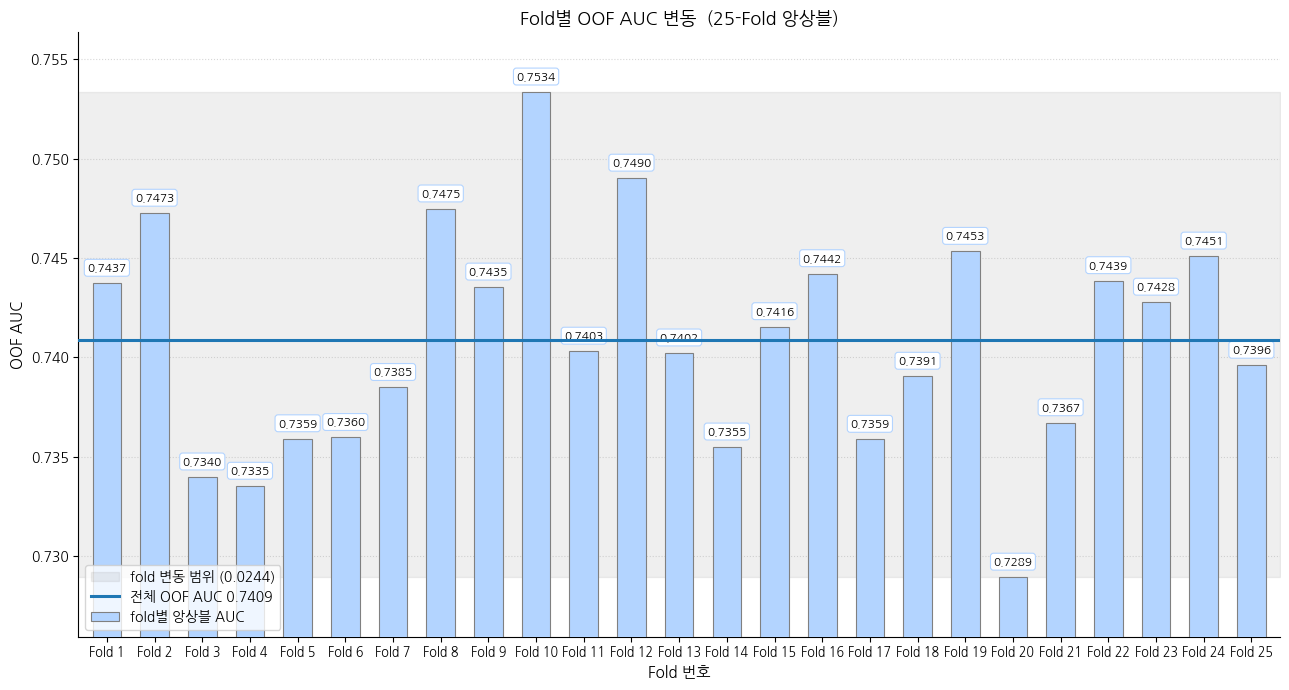


  핵심 메시지
fold별 AUC가 0.7289부터 0.7534까지 변동 폭 0.0244을 보입니다.
표준편차 0.0055로 fold 분할에 따른 자연스러운 분산이 관찰됩니다.
전체 OOF AUC 0.7409는 25개 fold 평균으로 안정된 성능 지표입니다.
이 변동 폭은 동일 모델·동일 데이터라도 fold 분할 운에 따라 발생하는
자연스러운 영역으로, 모델 자체의 본질적 성능 변화를 의미하지 않습니다.


In [ ]:
# ============================================================
# Fold별 OOF AUC 변동 분석 — fold 분할에 따른 자연스러운 변동 범위
# ============================================================

skf_for_eval = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

fold_auc_lgbm = []
fold_auc_cat  = []
fold_auc_ens  = []

# 학습 시 저장해 둔 oof 예측을 fold별로 잘라 AUC를 다시 계산합니다.
for fold_idx, (tr_idx, val_idx) in enumerate(skf_for_eval.split(X, y)):
    auc_l = roc_auc_score(y.iloc[val_idx], lgbm_oof[val_idx])
    auc_c = roc_auc_score(y.iloc[val_idx], cat_oof[val_idx])
    auc_e = roc_auc_score(y.iloc[val_idx], oof_ens[val_idx])
    fold_auc_lgbm.append(auc_l)
    fold_auc_cat.append(auc_c)
    fold_auc_ens.append(auc_e)

# 통계량 계산
fold_min   = min(fold_auc_ens)
fold_max   = max(fold_auc_ens)
fold_std   = np.std(fold_auc_ens)
fold_range = fold_max - fold_min
our_oof    = roc_auc_score(y, oof_ens)

print(f'fold별 앙상블 AUC: {fold_min:.4f} ~ {fold_max:.4f}  (변동 폭 {fold_range:.4f})')
print(f'fold AUC 표준편차: {fold_std:.4f}')
print(f'전체 OOF AUC:     {our_oof:.4f}')
print()

# ------------------------------------------------------------
# 시각화
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 7))

# 막대: 각 fold의 앙상블 AUC
x_pos = np.arange(1, N_SPLITS + 1)
bars = ax.bar(x_pos, fold_auc_ens, width=0.6,
              color='#B3D4FF', edgecolor='gray', linewidth=0.8,
              zorder=3, label='fold별 앙상블 AUC')

# 막대 위 수치 표시
for bar, val in zip(bars, fold_auc_ens):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      edgecolor='#B3D4FF', linewidth=0.8))

# fold 변동 범위를 회색 음영으로 강조
ax.fill_between([0.4, N_SPLITS + 0.6], [fold_min]*2, [fold_max]*2,
                alpha=0.12, color='gray', zorder=1,
                label=f'fold 변동 범위 ({fold_range:.4f})')

# 전체 OOF AUC 평균선 — 본 모델의 자체 성능 지표
ax.axhline(our_oof, color='#1F77B4', linestyle='-', linewidth=2.2,
           zorder=4, label=f'전체 OOF AUC {our_oof:.4f}')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'Fold {i}' for i in x_pos], fontsize=9)
ax.set_ylabel('OOF AUC', fontsize=11)
ax.set_xlabel('Fold 번호', fontsize=11)
ax.set_title(f'Fold별 OOF AUC 변동  ({N_SPLITS}-Fold 앙상블)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)

# y축 범위를 fold 변동 범위가 잘 보이도록 조정
y_min = fold_min - 0.003
y_max = fold_max + 0.003
ax.set_ylim(y_min, y_max)
ax.set_xlim(0.4, N_SPLITS + 0.6)

ax.yaxis.grid(True, linestyle=':', alpha=0.5, zorder=0)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fold_variation.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('=' * 60)
print('  핵심 메시지')
print('=' * 60)
print(f'fold별 AUC가 {fold_min:.4f}부터 {fold_max:.4f}까지 변동 폭 {fold_range:.4f}을 보입니다.')
print(f'표준편차 {fold_std:.4f}로 fold 분할에 따른 자연스러운 분산이 관찰됩니다.')
print(f'전체 OOF AUC {our_oof:.4f}는 25개 fold 평균으로 안정된 성능 지표입니다.')
print('이 변동 폭은 동일 모델·동일 데이터라도 fold 분할 운에 따라 발생하는')
print('자연스러운 영역으로, 모델 자체의 본질적 성능 변화를 의미하지 않습니다.')


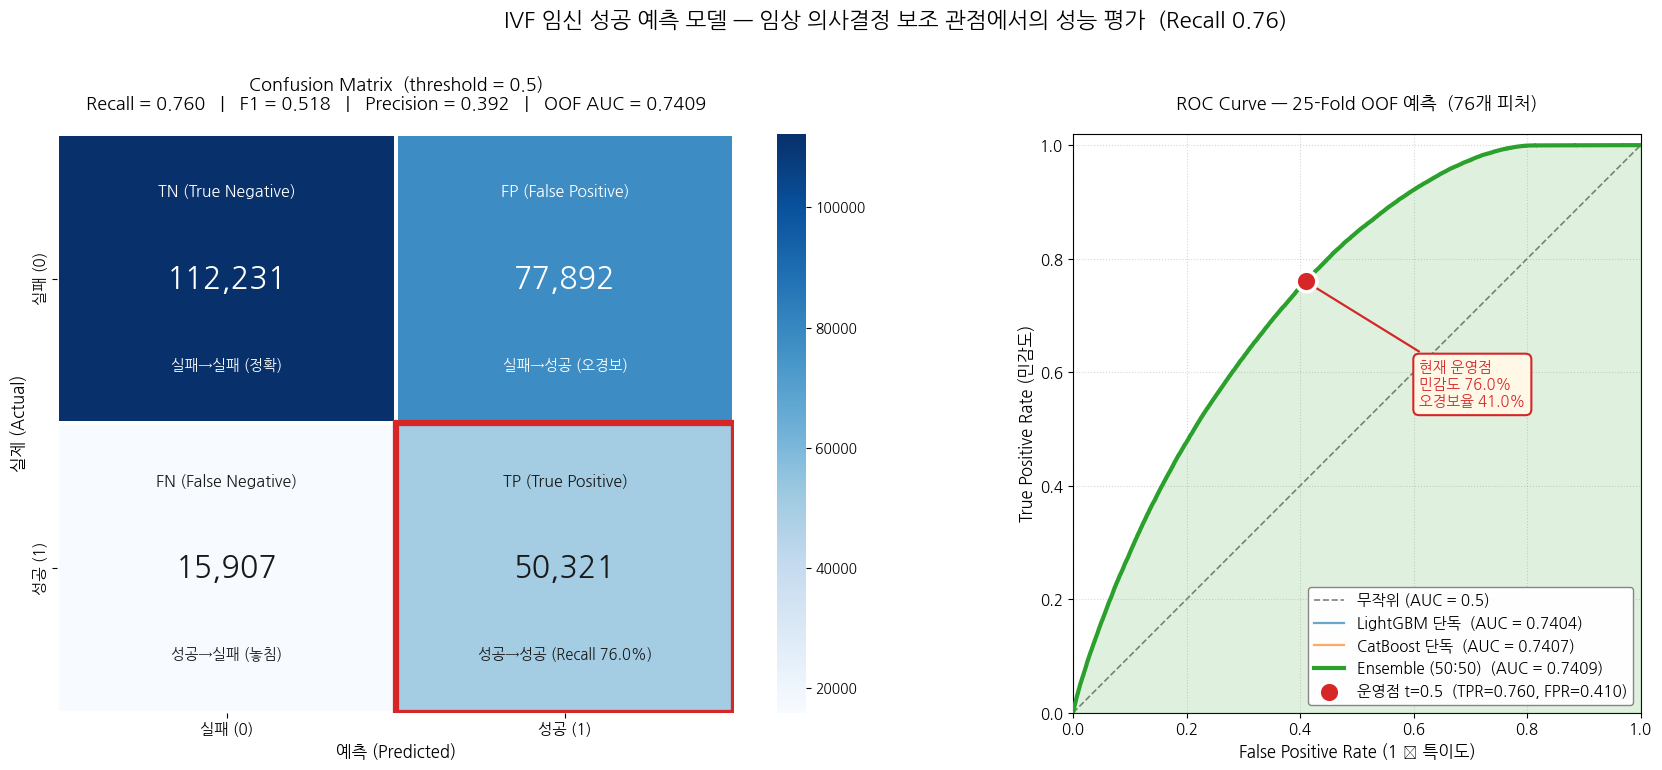

  Classification Report  (threshold = 0.5)

  Confusion Matrix:
                       예측 실패          예측 성공
    실제 실패 (0):        112,231 (TN)        77,892 (FP)
    실제 성공 (1):         15,907 (FN)        50,321 (TP)

  분류 지표:
    Precision         : 0.3925
    Recall (민감도)    : 0.7598   ← 실제 성공 케이스를 식별하는 비율
    F1 Score          : 0.5176

  AUC 비교:
    LightGBM 단독 OOF : 0.7404
    CatBoost 단독 OOF : 0.7407
    Ensemble OOF      : 0.7409   ← 본 노트북 최종 모델

  임상적 해석:
    실제 성공한 66,228명 중 50,321명(76.0%)을 모델이 식별
    실제 실패한 190,123명 중 77,892명(41.0%)을 잘못 양성 처리


In [ ]:
# ============================================================
# Confusion Matrix + ROC Curve
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score,
)

# ------------------------------------------------------------
# 1. 변수 매핑 — 학습 결과(OOF 예측)
# ------------------------------------------------------------
y_true       = y
y_pred_proba = oof_ens
y_pred_class = (y_pred_proba >= 0.5).astype(int)

# ------------------------------------------------------------
# 2. matrix 계산
# ------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred_class)
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
precision = precision_score(y_true, y_pred_class)
recall    = recall_score(y_true, y_pred_class)
f1        = f1_score(y_true, y_pred_class)

fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_true, lgbm_oof)
auc_lgbm = auc(fpr_lgbm, tpr_lgbm)
fpr_cat, tpr_cat, _ = roc_curve(y_true, cat_oof)
auc_cat = auc(fpr_cat, tpr_cat)

# threshold = 0.5에 해당하는 운영점 좌표
op_idx = int(np.argmin(np.abs(thresholds - 0.5)))
op_fpr, op_tpr = fpr[op_idx], tpr[op_idx]

# ------------------------------------------------------------
# 3. Confusion Matrix 셀 텍스트 사전 정의 (3계층: 헤더/카운트/의미)
# ------------------------------------------------------------
headers  = [['TN (True Negative)',  'FP (False Positive)'],
            ['FN (False Negative)', 'TP (True Positive)']]
counts   = [[tn, fp],
            [fn, tp]]
meanings = [['실패→실패 (정확)',  '실패→성공 (오경보)'],
            ['성공→실패 (놓침)',
             f'성공→성공 (Recall {recall*100:.1f}%)']]

# ============================================================
# 4. 시각화 — 1×2 레이아웃
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))

# ------------------------------------------------------------
# (왼쪽) Confusion Matrix
# ------------------------------------------------------------
sns.heatmap(
    cm, annot=False, cmap='Blues', cbar=True,
    xticklabels=['실패 (0)', '성공 (1)'],
    yticklabels=['실패 (0)', '성공 (1)'],
    linewidths=1.5, linecolor='white',
    ax=axes[0],
)

# 셀별 텍스트를 명도에 따라 흑/백 자동 분기로 배치
cm_max = cm.max()
for i in range(2):
    for j in range(2):
        text_color = 'white' if cm[i, j] > cm_max * 0.5 else '#1A1A1A'
        # 헤더 (위쪽)
        axes[0].text(j + 0.5, i + 0.20, headers[i][j],
                     ha='center', va='center',
                     fontsize=11.5, fontweight='bold', color=text_color)
        # 카운트 (가운데, 가장 크게 강조)
        axes[0].text(j + 0.5, i + 0.50, f'{counts[i][j]:,}',
                     ha='center', va='center',
                     fontsize=22, fontweight='bold', color=text_color)
        # 의미 (아래쪽)
        axes[0].text(j + 0.5, i + 0.80, meanings[i][j],
                     ha='center', va='center',
                     fontsize=10.5, color=text_color)

# TP 셀에 빨간 박스 — 실제 성공을 정확히 식별한 임상적 핵심 강조
tp_rect = Rectangle((1, 1), 1, 1, fill=False,
                    edgecolor='#D62728', linewidth=4.5, zorder=10)
axes[0].add_patch(tp_rect)

axes[0].set_title(
    f'Confusion Matrix  (threshold = 0.5)\n'
    f'Recall = {recall:.3f}   |   F1 = {f1:.3f}   |   '
    f'Precision = {precision:.3f}   |   OOF AUC = {roc_auc:.4f}',
    fontsize=13, pad=18, fontweight='bold',
)
axes[0].set_xlabel('예측 (Predicted)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('실제 (Actual)',   fontsize=12, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=11)

# ------------------------------------------------------------
# (오른쪽) ROC Curve
# ------------------------------------------------------------
# 무작위 기준선
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--',
             linewidth=1.2, label='무작위 (AUC = 0.5)', zorder=1)

# 단독 모델 — 얇고 반투명
axes[1].plot(fpr_lgbm, tpr_lgbm, color='#1F77B4', lw=1.6, alpha=0.65,
             label=f'LightGBM 단독  (AUC = {auc_lgbm:.4f})', zorder=2)
axes[1].plot(fpr_cat, tpr_cat, color='#FF7F0E', lw=1.6, alpha=0.65,
             label=f'CatBoost 단독  (AUC = {auc_cat:.4f})', zorder=2)

# 앙상블 — AUC 영역 음영 + 굵은 선
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#2CA02C', zorder=3)
axes[1].plot(fpr, tpr, color='#2CA02C', lw=3.0,
             label=f'Ensemble (50:50)  (AUC = {roc_auc:.4f})', zorder=4)

# 운영점 마커 — threshold=0.5에서의 (FPR, TPR)
axes[1].scatter(op_fpr, op_tpr, s=220, color='#D62728',
                edgecolor='white', linewidth=2.5, zorder=5,
                label=f'운영점 t=0.5  (TPR={op_tpr:.3f}, FPR={op_fpr:.3f})')

# 운영점 안내 박스
axes[1].annotate(
    f'현재 운영점\n민감도 {op_tpr*100:.1f}%\n오경보율 {op_fpr*100:.1f}%',
    xy=(op_fpr, op_tpr), xytext=(op_fpr + 0.20, op_tpr - 0.22),
    fontsize=10.5, color='#D62728', fontweight='bold', ha='left',
    arrowprops=dict(arrowstyle='->', color='#D62728', lw=1.6),
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF8E7',
              edgecolor='#D62728', linewidth=1.5),
)

axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel('False Positive Rate (1 − 특이도)',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Positive Rate (민감도)',
                   fontsize=12, fontweight='bold')
axes[1].set_title(f'ROC Curve — {N_SPLITS}-Fold OOF 예측  (76개 피처)',
                  fontsize=13, pad=18, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=11,
               framealpha=0.95, edgecolor='gray')
axes[1].grid(True, linestyle=':', alpha=0.5)
axes[1].tick_params(axis='both', labelsize=11)
axes[1].set_aspect('equal', adjustable='box')

# ------------------------------------------------------------
# 5. 전체 헤더 — 임상 의사결정 보조 도구 관점
# ------------------------------------------------------------
plt.suptitle(
    f'IVF 임신 성공 예측 모델 — 임상 의사결정 보조 관점에서의 성능 평가  '
    f'(Recall {recall:.2f})',
    fontsize=16, fontweight='bold', y=1.02,
)

plt.tight_layout()
plt.savefig('confusion_matrix_roc.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 6. 분류 리포트 출력
# ============================================================
print('=' * 65)
print('  Classification Report  (threshold = 0.5)')
print('=' * 65)
print()
print('  Confusion Matrix:')
print('                       예측 실패          예측 성공')
print(f'    실제 실패 (0):    {tn:>11,} (TN)   {fp:>11,} (FP)')
print(f'    실제 성공 (1):    {fn:>11,} (FN)   {tp:>11,} (TP)')
print()
print('  분류 지표:')
print(f'    Precision         : {precision:.4f}')
print(f'    Recall (민감도)    : {recall:.4f}   ← 실제 성공 케이스를 식별하는 비율')
print(f'    F1 Score          : {f1:.4f}')
print()
print('  AUC 비교:')
print(f'    LightGBM 단독 OOF : {auc_lgbm:.4f}')
print(f'    CatBoost 단독 OOF : {auc_cat:.4f}')
print(f'    Ensemble OOF      : {roc_auc:.4f}   ← 본 노트북 최종 모델')
print()
print('  임상적 해석:')
print(f'    실제 성공한 {tp+fn:,}명 중 {tp:,}명({recall*100:.1f}%)을 모델이 식별')
print(f'    실제 실패한 {tn+fp:,}명 중 {fp:,}명({fp/(tn+fp)*100:.1f}%)을 잘못 양성 처리')
print('=' * 65)


---
## Part 4. 피처 중요도 분석


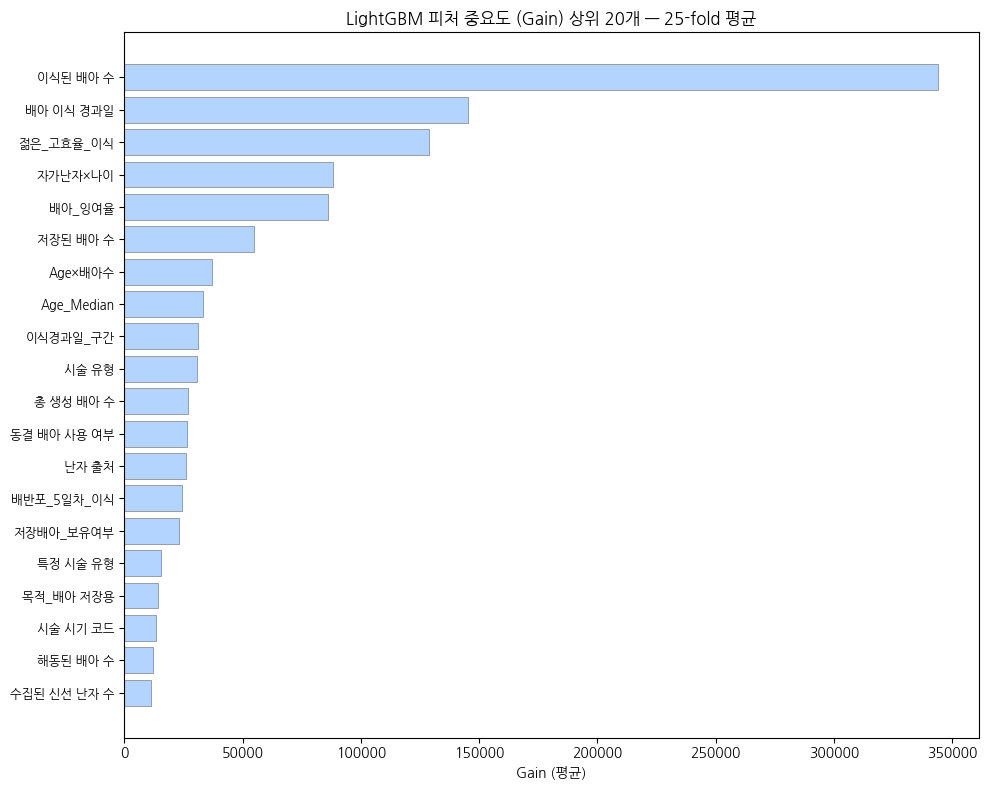


피처 중요도 상위 10개
        피처          Gain
  이식된 배아 수 344041.796281
 배아 이식 경과일 145261.589344
 젊은_고효율_이식 129008.856776
   자가난자×나이  88357.113142
    배아_잉여율  85984.892825
  저장된 배아 수  54855.301519
   Age×배아수  37260.467904
Age_Median  33412.879028
  이식경과일_구간  31052.720403
     시술 유형  30774.421627

해석 참고:
  - 상위 변수의 상당수가 도메인 지식으로 만든 파생 변수입니다.
  - 자가난자×나이, Age×배아수, 배아_잉여율은 새로 만든 변수이며
    원본 컬럼을 그대로 사용한 것보다 더 높은 중요도를 보입니다.
  - 이는 임상 패턴을 변수에 반영한 도메인 기반 설계가 효과적이었음을 시사합니다.


In [ ]:
# ============================================================
# K-fold 평균 피처 중요도
# ============================================================

gain_matrix = np.array([
    m.booster_.feature_importance(importance_type='gain')
    for m in lgbm_models
])

# K개 fold의 평균을 사용하여 데이터프레임으로 정리합니다.
fi_gain = pd.DataFrame({
    '피처':  X.columns,
    'Gain':  gain_matrix.mean(axis=0),
}).sort_values('Gain', ascending=False).reset_index(drop=True)

# ------------------------------------------------------------
# 상위 20개 시각화
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))
top20 = fi_gain.head(20)
ax.barh(range(20), top20['Gain'].values[::-1],
        color='#B3D4FF', edgecolor='gray', linewidth=0.5)
ax.set_yticks(range(20))
ax.set_yticklabels(top20['피처'].values[::-1], fontsize=9)
ax.set_title(f'LightGBM 피처 중요도 (Gain) 상위 20개 — {N_SPLITS}-fold 평균', fontsize=12)
ax.set_xlabel('Gain (평균)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('피처 중요도 상위 10개')
print(fi_gain.head(10).to_string(index=False))
print()
print('해석 참고:')
print('  - 상위 변수의 상당수가 도메인 지식으로 만든 파생 변수입니다.')
print('  - 자가난자×나이, Age×배아수, 배아_잉여율은 새로 만든 변수이며')
print('    원본 컬럼을 그대로 사용한 것보다 더 높은 중요도를 보입니다.')
print('  - 이는 임상 패턴을 변수에 반영한 도메인 기반 설계가 효과적이었음을 시사합니다.')

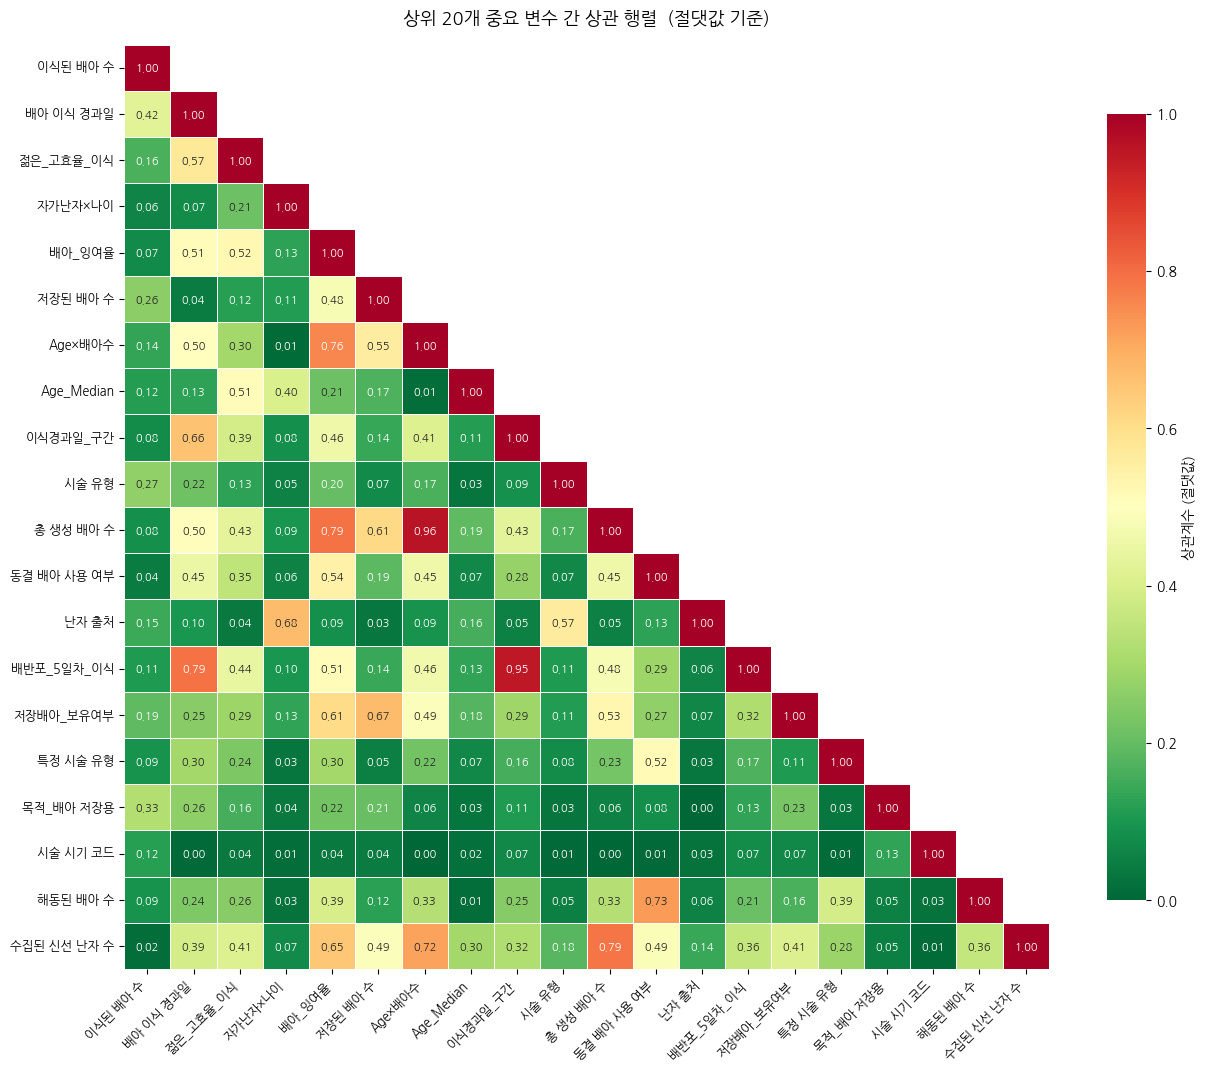


  상관계수 |r| > 0.7 인 변수 페어
  |r|=0.958  |  Age×배아수  ↔  총 생성 배아 수
  |r|=0.946  |  이식경과일_구간  ↔  배반포_5일차_이식
  |r|=0.791  |  배아_잉여율  ↔  총 생성 배아 수
  |r|=0.790  |  배아 이식 경과일  ↔  배반포_5일차_이식
  |r|=0.786  |  총 생성 배아 수  ↔  수집된 신선 난자 수
  |r|=0.760  |  배아_잉여율  ↔  Age×배아수
  |r|=0.729  |  동결 배아 사용 여부  ↔  해동된 배아 수
  |r|=0.718  |  Age×배아수  ↔  수집된 신선 난자 수

해석 안내
  - 상관이 높은 변수들은 비슷한 정보를 담고 있어, 한쪽만 있어도 같은 효과를 냅니다.
  - 이 데이터에서 자주 함께 등장하는 정보:
    • 배아/난자 수 관련 변수들 (총 생성, 이식, 저장이 함께 움직임)
    • 시술 횟수, 임신 횟수 관련 변수들 (이력 변수들의 군집)
  - 트리 모델은 이러한 중복에 강인하나, 독립적 신호를 가진 변수가 더 가치 있습니다.


In [ ]:
# ============================================================
# 상위 20개 중요 변수의 상관 행렬 — 다중공선성 점검
# ============================================================

top20_features = fi_gain.head(20)['피처'].tolist()

# category dtype 변수는 코드로 변환해야 상관 계산 가능
X_top20 = X[top20_features].copy()
for col in X_top20.columns:
    if X_top20[col].dtype.name == 'category':
        # category 코드는 0, 1, 2 ... 로 매핑된 정수입니다.
        X_top20[col] = X_top20[col].cat.codes

# 절댓값 상관 행렬 (방향성 무시, 강도만 본다)
corr_matrix = X_top20.corr().abs()

# ------------------------------------------------------------
# 시각화
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 11))

# 대각선보다 위쪽만 마스킹하여 깔끔하게 표시
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn_r',   # 빨강(높은 상관) → 노랑 → 초록(낮은 상관)
    vmin=0, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 8, 'weight': 'bold'},
    cbar_kws={'label': '상관계수 (절댓값)', 'shrink': 0.8},
    square=True,
    ax=ax,
)

ax.set_title('상위 20개 중요 변수 간 상관 행렬  (절댓값 기준)',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 강한 상관 페어 자동 추출
# ------------------------------------------------------------
# 본인-본인은 1이므로 제외하고, 절댓값이 높은 페어를 출력합니다.
high_corr_pairs = []
for i in range(len(top20_features)):
    for j in range(i + 1, len(top20_features)):
        r = corr_matrix.iloc[i, j]
        if r > 0.7:
            high_corr_pairs.append((top20_features[i], top20_features[j], r))

high_corr_pairs.sort(key=lambda x: x[2], reverse=True)

print()
print('=' * 60)
print('  상관계수 |r| > 0.7 인 변수 페어')
print('=' * 60)
if high_corr_pairs:
    for var1, var2, r in high_corr_pairs[:15]:
        print(f'  |r|={r:.3f}  |  {var1}  ↔  {var2}')
else:
    print('  높은 상관(|r| > 0.7)을 보이는 페어가 없습니다.')

print()
print('해석 안내')
print('  - 상관이 높은 변수들은 비슷한 정보를 담고 있어, 한쪽만 있어도 같은 효과를 냅니다.')
print('  - 이 데이터에서 자주 함께 등장하는 정보:')
print('    • 배아/난자 수 관련 변수들 (총 생성, 이식, 저장이 함께 움직임)')
print('    • 시술 횟수, 임신 횟수 관련 변수들 (이력 변수들의 군집)')
print('  - 트리 모델은 이러한 중복에 강인하나, 독립적 신호를 가진 변수가 더 가치 있습니다.')


---
## Part 5. SHAP 분석


In [ ]:
# ============================================================
# SHAP 라이브러리 준비 및 분석 대상 데이터 추출
# ============================================================

!pip install shap --quiet

import shap

# ------------------------------------------------------------
# 분석에 사용할 모델과 데이터 선택
# ------------------------------------------------------------
# K개 fold 모델 중 가장 OOF AUC가 높은 모델 하나를 선택해 SHAP 분석을 수행합니다.
# 모든 모델을 다 분석하면 시간이 오래 걸리므로, 대표 모델 하나로 충분히 인사이트를 얻을 수 있습니다.
# 누수 점검: 학습 데이터(X, y)와 학습된 모델(lgbm_models)만 사용합니다.
# test 데이터는 사용하지 않습니다.

# 각 fold의 검증 AUC를 다시 계산하여 가장 높은 모델 선정
skf_for_shap = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
fold_aucs_for_shap = []
for fold_idx, (_, val_idx) in enumerate(skf_for_shap.split(X, y)):
    auc = roc_auc_score(y.iloc[val_idx], lgbm_oof[val_idx])
    fold_aucs_for_shap.append(auc)

best_fold = int(np.argmax(fold_aucs_for_shap))
shap_model = lgbm_models[best_fold]
print(f'SHAP 분석에 사용할 모델: Fold {best_fold + 1} '
      f'(검증 AUC = {fold_aucs_for_shap[best_fold]:.4f})')

# ------------------------------------------------------------
# 분석용 샘플 데이터 추출
# ------------------------------------------------------------
# 전체 25만 행에 대해 SHAP 값을 계산하면 5분 이상 걸리고 시각화도 무거워집니다.
# 대신 무작위로 추출한 10,000행으로 분석하면 동일한 인사이트를 빠르게 얻을 수 있습니다.
# 통계적으로 1만 건 정도면 변수의 평균적 영향을 안정적으로 추정할 수 있습니다.
SHAP_SAMPLE_SIZE = 10000
np.random.seed(42)
sample_idx = np.random.choice(len(X), size=min(SHAP_SAMPLE_SIZE, len(X)), replace=False)
X_shap = X.iloc[sample_idx].copy()
y_shap = y.iloc[sample_idx].copy()
oof_shap = oof_ens[sample_idx]

print(f'분석 샘플: {len(X_shap):,}행')
print(f'  실패 (0): {(y_shap == 0).sum():,}건')
print(f'  성공 (1): {(y_shap == 1).sum():,}건')

# ------------------------------------------------------------
# TreeExplainer 생성 (LightGBM은 매우 빠름)
# ------------------------------------------------------------
# TreeExplainer는 트리 모델 전용 SHAP 계산기로, 일반 SHAP보다 수십 배 빠릅니다.
# LightGBM 모델 객체를 받아 분석을 시작합니다.
print('\nSHAP TreeExplainer 생성 중...')
explainer = shap.TreeExplainer(shap_model)

print('SHAP 값 계산 중... (약 1~3분 소요)')
# shap_values는 (n_samples, n_features) 형태의 배열입니다.
# 각 원소는 그 환자의 그 변수가 예측에 미친 영향을 나타냅니다.
shap_values = explainer.shap_values(X_shap)

# 이진 분류에서 일부 SHAP 버전은 [class_0, class_1] 두 배열을 반환합니다.
# 우리는 양성 클래스(임신 성공) 기준으로 분석하므로 [1] 인덱스를 사용합니다.
if isinstance(shap_values, list):
    shap_values = shap_values[1]
    expected_value = explainer.expected_value[1]
else:
    expected_value = explainer.expected_value

print(f'SHAP 값 행렬: {shap_values.shape}')
print(f'기준값 E[f(X)]: {expected_value:.4f}')
print()
print('계산이 완료되었습니다. 다음 셀에서 시각화를 수행합니다.')

SHAP 분석에 사용할 모델: Fold 10 (검증 AUC = 0.7526)
분석 샘플: 10,000행
  실패 (0): 7,525건
  성공 (1): 2,475건

SHAP TreeExplainer 생성 중...
SHAP 값 계산 중... (약 1~3분 소요)
SHAP 값 행렬: (10000, 76)
기준값 E[f(X)]: -0.7464

계산이 완료되었습니다. 다음 셀에서 시각화를 수행합니다.


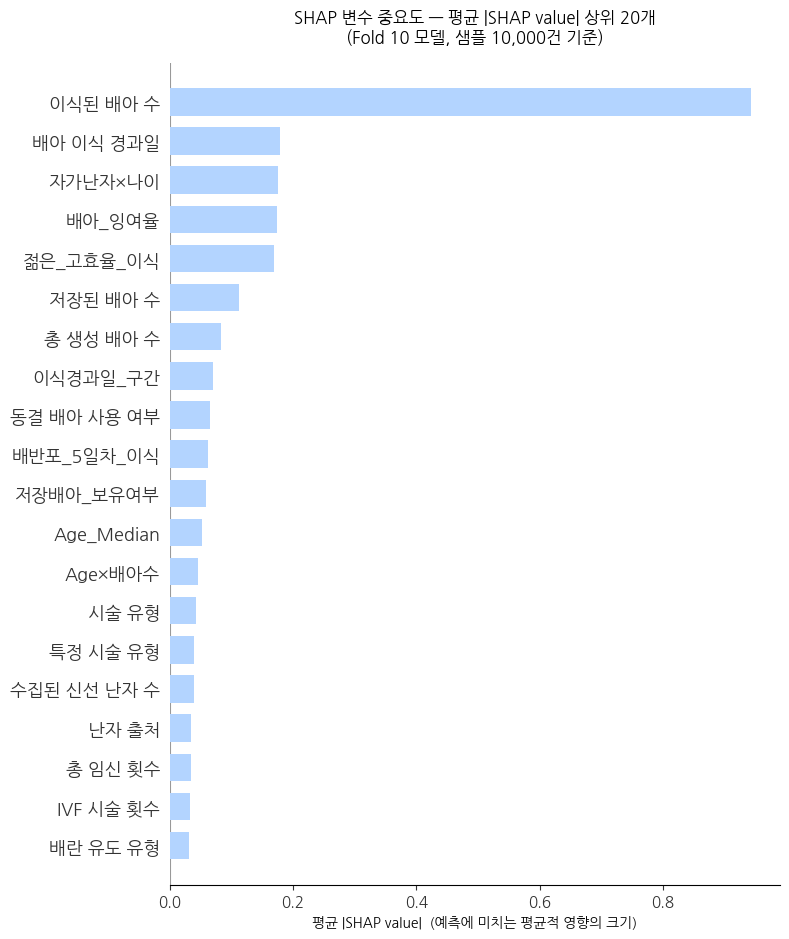


SHAP 기준 상위 10개 변수
         피처  Mean_|SHAP|
   이식된 배아 수     0.942445
  배아 이식 경과일     0.179181
    자가난자×나이     0.175521
     배아_잉여율     0.173578
  젊은_고효율_이식     0.168489
   저장된 배아 수     0.112153
  총 생성 배아 수     0.082862
   이식경과일_구간     0.069641
동결 배아 사용 여부     0.064566
 배반포_5일차_이식     0.061817

Gain 기준 상위 10개와 비교
 SHAP 순위     SHAP 변수    Gain 변수
       1    이식된 배아 수   이식된 배아 수
       2   배아 이식 경과일  배아 이식 경과일
       3     자가난자×나이  젊은_고효율_이식
       4      배아_잉여율    자가난자×나이
       5   젊은_고효율_이식     배아_잉여율
       6    저장된 배아 수   저장된 배아 수
       7   총 생성 배아 수    Age×배아수
       8    이식경과일_구간 Age_Median
       9 동결 배아 사용 여부   이식경과일_구간
      10  배반포_5일차_이식      시술 유형


In [ ]:
# ============================================================
# SHAP 시각화 1 — Summary Plot (Bar)
# ============================================================

fig = plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap,
    plot_type='bar',
    max_display=20,
    show=False,
    color='#B3D4FF',
)
ax = plt.gca()
ax.set_title(f'SHAP 변수 중요도 — 평균 |SHAP value| 상위 20개\n'
             f'(Fold {best_fold + 1} 모델, 샘플 {len(X_shap):,}건 기준)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('평균 |SHAP value|  (예측에 미치는 평균적 영향의 크기)', fontsize=10)
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Gain importance와 SHAP 중요도의 상위 5개 비교
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({
    '피처': X_shap.columns,
    'Mean_|SHAP|': mean_abs_shap,
}).sort_values('Mean_|SHAP|', ascending=False).reset_index(drop=True)

print()
print('SHAP 기준 상위 10개 변수')
print(shap_importance_df.head(10).to_string(index=False))
print()
print('Gain 기준 상위 10개와 비교')
comparison = pd.DataFrame({
    'SHAP 순위': range(1, 11),
    'SHAP 변수': shap_importance_df.head(10)['피처'].values,
    'Gain 변수': fi_gain.head(10)['피처'].values,
})
print(comparison.to_string(index=False))

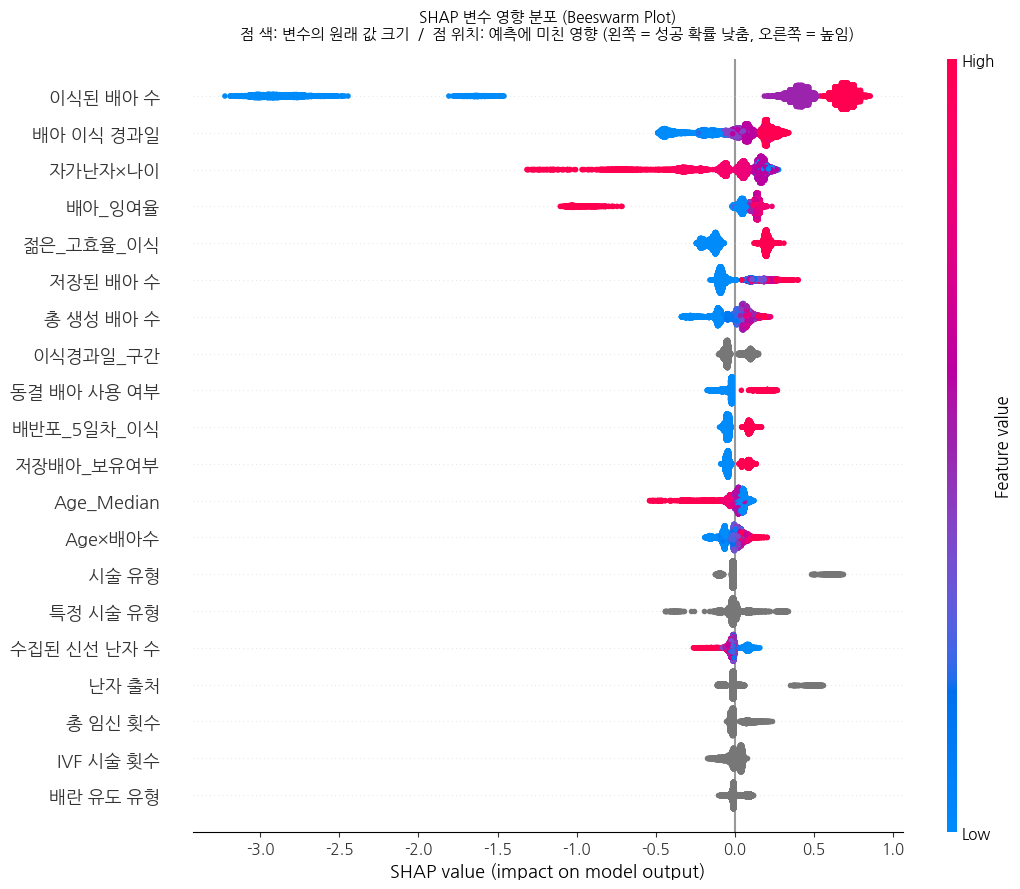


이 그래프에서 확인할 수 있는 것
  1. 변수의 영향 크기 (가로 폭)
  2. 변수의 영향 방향 (왼쪽/오른쪽)
  3. 변수의 원래 값과 영향의 관계 (점 색)

해석 예시
  - 나이 관련 변수에서 빨간 점(고령)이 왼쪽에, 파란 점(저연령)이 오른쪽에 배치되어 있다면,
    나이가 들수록 임신 성공 예측 확률이 떨어지는 일관된 패턴을 보입니다.
  - 이식된 배아 수에서 빨간 점이 오른쪽에 있다면, 이식 수가 많을수록 성공 예측이 올라간다는 의미입니다.


In [ ]:
# ============================================================
# SHAP 시각화 2 — Summary Plot (Beeswarm)
# ============================================================

fig = plt.figure(figsize=(11, 9))
shap.summary_plot(
    shap_values, X_shap,
    max_display=20,
    show=False,
    plot_size=None,
)
ax = plt.gca()
ax.set_title(f'SHAP 변수 영향 분포 (Beeswarm Plot)\n'
             f'점 색: 변수의 원래 값 크기  /  점 위치: 예측에 미친 영향 (왼쪽 = 성공 확률 낮춤, 오른쪽 = 높임)',
             fontsize=11, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('이 그래프에서 확인할 수 있는 것')
print('  1. 변수의 영향 크기 (가로 폭)')
print('  2. 변수의 영향 방향 (왼쪽/오른쪽)')
print('  3. 변수의 원래 값과 영향의 관계 (점 색)')
print()
print('해석 예시')
print('  - 나이 관련 변수에서 빨간 점(고령)이 왼쪽에, 파란 점(저연령)이 오른쪽에 배치되어 있다면,')
print('    나이가 들수록 임신 성공 예측 확률이 떨어지는 일관된 패턴을 보입니다.')
print('  - 이식된 배아 수에서 빨간 점이 오른쪽에 있다면, 이식 수가 많을수록 성공 예측이 올라간다는 의미입니다.')

분석 대상 환자: 샘플 인덱스 893
  모델 예측 확률: 0.9999
  실제 결과:      실패



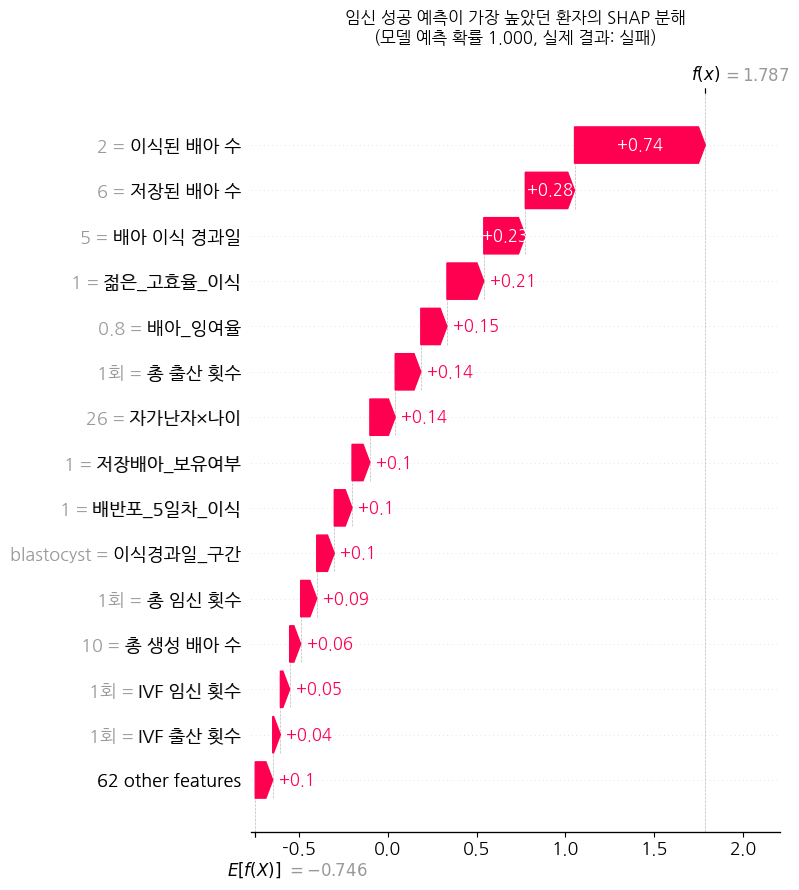


읽는 방법
  - E[f(X)] = -0.746: 모든 환자의 평균 예측 (출발점)
  - f(x)   = 1.787: 이 환자의 최종 예측
  - 빨간 막대 (오른쪽): 성공 확률을 끌어올린 변수
  - 파란 막대 (왼쪽):  성공 확률을 끌어내린 변수

해석: 이 환자에서 가장 큰 양의 영향을 준 변수들이 임상적으로 어떤 의미인지 확인할 수 있습니다.


In [ ]:
# ============================================================
# SHAP 시각화 3 — Waterfall Plot (임신 성공 예측이 가장 높은 한 환자)
# ============================================================

top_success_idx = int(np.argmax(oof_shap))
top_success_prob = oof_shap[top_success_idx]
top_success_actual = y_shap.iloc[top_success_idx]

print(f'분석 대상 환자: 샘플 인덱스 {top_success_idx}')
print(f'  모델 예측 확률: {top_success_prob:.4f}')
print(f'  실제 결과:      {"성공" if top_success_actual == 1 else "실패"}')
print()

fig = plt.figure(figsize=(11, 8))

# SHAP 0.40+ 의 Explanation 객체로 만들어 waterfall에 전달
explanation = shap.Explanation(
    values=shap_values[top_success_idx],
    base_values=expected_value,
    data=X_shap.iloc[top_success_idx].values,
    feature_names=list(X_shap.columns),
)

shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title(f'임신 성공 예측이 가장 높았던 환자의 SHAP 분해\n'
          f'(모델 예측 확률 {top_success_prob:.3f}, 실제 결과: {"성공" if top_success_actual == 1 else "실패"})',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_waterfall_success.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('읽는 방법')
print('  - E[f(X)] = {:.3f}: 모든 환자의 평균 예측 (출발점)'.format(expected_value))
print('  - f(x)   = {:.3f}: 이 환자의 최종 예측'.format(
    expected_value + shap_values[top_success_idx].sum()))
print('  - 빨간 막대 (오른쪽): 성공 확률을 끌어올린 변수')
print('  - 파란 막대 (왼쪽):  성공 확률을 끌어내린 변수')
print()
print('해석: 이 환자에서 가장 큰 양의 영향을 준 변수들이 임상적으로 어떤 의미인지 확인할 수 있습니다.')

분석 대상 환자: 샘플 인덱스 2272
  모델 예측 확률: 0.0001
  실제 결과:      실패



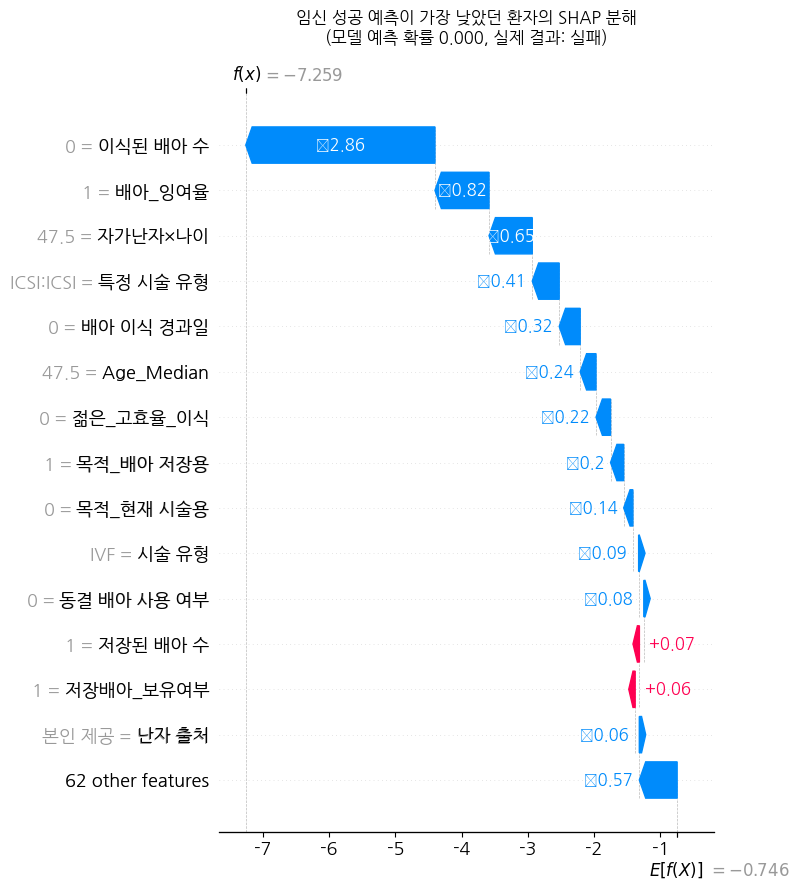


두 환자 비교 — 성공 vs 실패의 SHAP 분해는 어떻게 다른가
  성공 예측 환자 (1.000): 양의 SHAP 합 = +2.533
  실패 예측 환자 (0.000): 양의 SHAP 합 = -6.513

관찰: 두 환자의 SHAP 합이 정반대 방향으로 나타납니다.
해석: 같은 모델이 동일한 변수들을 보고도 환자별 상황에 따라
      양/음 두 방향 모두로 영향을 부여한다는 점이 트리 모델의 비선형 학습 능력을 잘 보여 줍니다.


In [ ]:
# ============================================================
# SHAP 시각화 4 — Waterfall Plot (임신 성공 예측이 가장 낮은 한 환자)
# ============================================================

top_fail_idx = int(np.argmin(oof_shap))
top_fail_prob = oof_shap[top_fail_idx]
top_fail_actual = y_shap.iloc[top_fail_idx]

print(f'분석 대상 환자: 샘플 인덱스 {top_fail_idx}')
print(f'  모델 예측 확률: {top_fail_prob:.4f}')
print(f'  실제 결과:      {"성공" if top_fail_actual == 1 else "실패"}')
print()

fig = plt.figure(figsize=(11, 8))

explanation_fail = shap.Explanation(
    values=shap_values[top_fail_idx],
    base_values=expected_value,
    data=X_shap.iloc[top_fail_idx].values,
    feature_names=list(X_shap.columns),
)

shap.plots.waterfall(explanation_fail, max_display=15, show=False)
plt.title(f'임신 성공 예측이 가장 낮았던 환자의 SHAP 분해\n'
          f'(모델 예측 확률 {top_fail_prob:.3f}, 실제 결과: {"성공" if top_fail_actual == 1 else "실패"})',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_waterfall_fail.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('두 환자 비교 — 성공 vs 실패의 SHAP 분해는 어떻게 다른가')
print(f'  성공 예측 환자 ({top_success_prob:.3f}): 양의 SHAP 합 = {shap_values[top_success_idx].sum():+.3f}')
print(f'  실패 예측 환자 ({top_fail_prob:.3f}): 양의 SHAP 합 = {shap_values[top_fail_idx].sum():+.3f}')
print()
print('관찰: 두 환자의 SHAP 합이 정반대 방향으로 나타납니다.')
print('해석: 같은 모델이 동일한 변수들을 보고도 환자별 상황에 따라')
print('      양/음 두 방향 모두로 영향을 부여한다는 점이 트리 모델의 비선형 학습 능력을 잘 보여 줍니다.')

In [ ]:
# ============================================================
# 최종 결과 요약 (v10 — 팀원 피처 5개 추가 ablation)
# ============================================================

ensemble_auc = roc_auc_score(y, oof_ens)

print('=' * 60)
print('              v10 학습 결과 요약')
print('=' * 60)
print()
print(f'  데이터:           학습 {X.shape[0]:,}행 × {X.shape[1]}개 변수 (v9 대비 +5)')
print(f'  설정:             N_SPLITS={N_SPLITS}, USE_RANK_AVG={USE_RANK_AVG}')
print()
print(f'  LightGBM OOF:     {lgbm_auc:.4f}')
print(f'  CatBoost OOF:     {cat_auc:.4f}')
print(f'  앙상블 OOF:       {ensemble_auc:.4f}')
print()
print('=' * 60)
print('  v9 (71개) vs v10 (76개) 비교')
print('=' * 60)
print(f'  v9 OOF (71개):    0.7408')
print(f'  v10 OOF (76개):   {ensemble_auc:.4f}')
print(f'  변화:             {ensemble_auc - 0.7408:+.4f}')
print()
print('=' * 60)
print('  추가된 팀원 피처 5개 — 중요도 확인')
print('=' * 60)
team_features = ['배반포_5일차_이식', '젊은_고효율_이식', '이식경과일_구간', '동결_기증_복합', '고령_반복시술']
for feat in team_features:
    if feat in fi_gain['피처'].values:
        rank = fi_gain[fi_gain['피처'] == feat].index[0] + 1
        gain = fi_gain[fi_gain['피처'] == feat]['Gain'].values[0]
        print(f'  {feat:20s}: 순위 {rank:>3d}/76, Gain {gain:>10,.0f}')
print()
print(f'  중요도 전체 1위: {fi_gain.iloc[0]["피처"]}')
print(f'  중요도 전체 2위: {fi_gain.iloc[1]["피처"]}')
print(f'  중요도 전체 3위: {fi_gain.iloc[2]["피처"]}')
print()
print('=' * 60)
print('  본 노트북의 데이터 누수 방지 점검')
print('=' * 60)
print('  유형 1 (Train+Test concat):     통과 — 두 데이터를 합치지 않음')
print('  유형 2 (Test get_dummies):      통과 — MultiLabelBinarizer 클래스 하드코딩')
print('  유형 3 (Fold 전 fit):           통과 — Scaler/Imputer 미사용, 고정 상수만 사용')
print('  유형 4 (전체 데이터 selection): 통과 — Clustering/Selection 미사용')
print()
print('  팀원 피처 5개도 모두 동일 기준으로 통과 (행 단위 + 고정 상수)')
print('=' * 60)
print()
print('=' * 60)
print('  결과 해석 가이드')
print('=' * 60)
ensemble_change = ensemble_auc - 0.7408
if ensemble_change >= 0.0001:
    print(f'     OOF +{ensemble_change:.4f} 개선 → 팀원 피처가 의미 있는 신호 추가')
    print(f'     LB 제출을 검토하세요. 개선 가능성이 있습니다.')
elif ensemble_change >= 0:
    print(f'     OOF +{ensemble_change:.4f} 미세 개선 → 거의 동일 수준')
    print(f'     LB 제출 시 변화 미미. 발표 자료에 ablation 결과 포함.')
else:
    print(f'     OOF {ensemble_change:.4f} 하락 → 팀원 피처가 정보 중복으로 작용')
    print(f'     v9 (71개)이 최선임을 다시 확인. "단순함이 강함" 메시지 강화.')
print('=' * 60)

              v10 학습 결과 요약

  데이터:           학습 256,351행 × 76개 변수 (v9 대비 +5)
  설정:             N_SPLITS=25, USE_RANK_AVG=True

  LightGBM OOF:     0.7404
  CatBoost OOF:     0.7407
  앙상블 OOF:       0.7409

  v9 (71개) vs v10 (76개) 비교
  v9 OOF (71개):    0.7408
  v10 OOF (76개):   0.7409
  변화:             +0.0001

  추가된 팀원 피처 5개 — 중요도 확인
  배반포_5일차_이식          : 순위  14/76, Gain     24,219
  젊은_고효율_이식           : 순위   3/76, Gain    129,009
  이식경과일_구간            : 순위   9/76, Gain     31,053
  동결_기증_복합            : 순위  72/76, Gain        128
  고령_반복시술             : 순위  43/76, Gain      3,148

  중요도 전체 1위: 이식된 배아 수
  중요도 전체 2위: 배아 이식 경과일
  중요도 전체 3위: 젊은_고효율_이식

  본 노트북의 데이터 누수 방지 점검
  유형 1 (Train+Test concat):     통과 — 두 데이터를 합치지 않음
  유형 2 (Test get_dummies):      통과 — MultiLabelBinarizer 클래스 하드코딩
  유형 3 (Fold 전 fit):           통과 — Scaler/Imputer 미사용, 고정 상수만 사용
  유형 4 (전체 데이터 selection): 통과 — Clustering/Selection 미사용

  팀원 피처 5개도 모두 동일 기준으로 통과 (행 단위 + 고정 상수)

  결과 해석 가이드
     OOF +0.0001 미세 개선

In [ ]:
# ============================================================
# 모든 결과 파일을 ZIP으로 묶기
# ============================================================

import zipfile
import os

zip_path = '/kaggle/working/all_outputs.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for fname in sorted(os.listdir('/kaggle/working/')):
        full_path = f'/kaggle/working/{fname}'
        # 디렉토리는 제외, 파일만 (ZIP 자기 자신도 제외)
        if os.path.isfile(full_path) and fname != 'all_outputs.zip':
            if fname.endswith('.png') or fname.endswith('.csv'):
                zipf.write(full_path, fname)
                print(f"  추가: {fname}")

print()
print(f"ZIP 파일 생성 완료: all_outputs.zip")
print(f"우측 Output 패널에서 'all_outputs.zip' 다운로드하세요.")

  추가: confusion_matrix_roc.png
  추가: correlation_matrix.png
  추가: feature_importance.png
  추가: fold_variation.png
  추가: shap_summary_bar.png
  추가: shap_summary_beeswarm.png
  추가: shap_waterfall_fail.png
  추가: shap_waterfall_success.png
  추가: submission_v10_team_25fold_rank.csv

ZIP 파일 생성 완료: all_outputs.zip
우측 Output 패널에서 'all_outputs.zip' 다운로드하세요.
